# TAAC2026 Sample Data Analysis (`demo_1000.parquet`)

本 notebook 对官方提供的 1000 行 sample data (`demo_1000.parquet`) 进行系统性分析：

1. **概览**：行数、列数、列类型分布、各特征族（user_int / user_dense / item_int / domain_a-d_seq）
2. **标签与时间**：`label_type` 分布、`timestamp` / `label_time` 时序情况
3. **用户离散标量特征**：低基数推断（性别、省份、年龄段、二值标志等）+ 分布图
4. **用户离散多值特征**：list 长度、取值分布（兴趣标签/历史品类等）
5. **用户 dense 特征**：embedding 形态（256/320 维）与原值统计形态
6. **物料离散特征**：行业/品类/创意类型推断
7. **行为序列特征**：四个 domain 的长度、缺失率、值域、时间桶
8. **特征语义猜测汇总表**

参考格式：`/Users/gaogang/study/taac2026/dataanalysis.ipynb`。

## 1. 数据加载与总览

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# ---- 中文字体设置（解决图表里中文显示为方块的问题）----
_preferred = [
    'PingFang SC', 'PingFang HK', 'Heiti SC', 'Heiti TC', 'STHeiti',
    'Hiragino Sans GB', 'Songti SC', 'Arial Unicode MS',  # macOS
    'Microsoft YaHei', 'SimHei',                          # Windows
    'Noto Sans CJK SC', 'WenQuanYi Zen Hei', 'DejaVu Sans'  # Linux 兜底
]
_available = {f.name for f in fm.fontManager.ttflist}
_chosen = next((f for f in _preferred if f in _available), 'DejaVu Sans')
matplotlib.rcParams['font.sans-serif'] = [_chosen] + matplotlib.rcParams['font.sans-serif']
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['figure.dpi'] = 100
print('matplotlib 中文字体使用:', _chosen)

print('cwd:', os.getcwd())
df = pd.read_parquet('demo_1000.parquet')
print('shape:', df.shape)
df.head()

matplotlib 中文字体使用: PingFang HK
cwd: /Users/gaogang/study/taac2026/TAAC2026Baseline


shape: (1000, 120)


,user_id,item_id,label_type,label_time,timestamp,user_int_feats_1,user_int_feats_3,user_int_feats_4,user_int_feats_15,user_int_feats_48,...,domain_d_seq_17,domain_d_seq_18,domain_d_seq_19,domain_d_seq_20,domain_d_seq_21,domain_d_seq_22,domain_d_seq_23,domain_d_seq_24,domain_d_seq_25,domain_d_seq_26
0,3864676,103989760,1,1772725413,1772725140,4,1753.0,6.0,"[928, 556, 538, 739, 94]",42.0,...,"[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...","[51, 193, 310, 310, 114, 227, 18, 831, 831, 83...","[0, 0, 1258, 1258, 143, 1599, 1475, 951, 951, ...","[0, 0, 188, 188, 1807, 0, 5762, 0, 0, 0, 1484,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1048, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[217882, 290672, 117875, 117875, 90767, 0, 469...","[0, 0, 67, 0, 0, 548, 511, 231, 231, 0, 0, 548...","[2, 2, 2, 14, 2, 7, 12, 2, 11, 10, 13, 2, 8, 7...","[1772723880, 1772721120, 1772721120, 177272094..."
1,8507274,106263941,1,1772725312,1772725252,4,1137.0,601.0,"[147, 50, 757]",44.0,...,None,None,None,None,None,None,None,None,None,None
2,11951382,44791352,1,1772725742,1772725278,4,1295.0,63.0,"[982, 349, 387, 974, 976, 213]",82.0,...,"[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...","[256, 899, 33, 256, 899, 882, 256, 200, 732, 8...","[982, 0, 2095, 395, 0, 1411, 416, 1413, 1343, ...","[0, 0, 6235, 0, 0, 11073, 0, 7319, 0, 0, 0, 0,...","[0, 0, 0, 0, 0, 349, 0, 973, 0, 0, 0, 0, 0, 0,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[180661, 289210, 557858, 615514, 233370, 42275...","[0, 306, 67, 548, 102, 465, 548, 548, 548, 0, ...","[2, 11, 11, 2, 7, 13, 7, 8, 12, 14, 13, 11, 7,...","[1772725200, 1772725140, 1772724960, 177272496..."
3,3971927,82207201,1,1772725701,1772725385,4,572.0,45.0,"[115, 842, 562, 535, 153]",92.0,...,"[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...","[95, 113, 436, 882, 737, 840, 968, 678, 113, 9...","[334, 132, 3144, 2565, 0, 0, 2507, 0, 132, 305...","[0, 0, 7843, 6835, 0, 0, 8070, 0, 1516, 0, 559...","[0, 0, 0, 2678, 0, 0, 0, 0, 0, 0, 0, 0, 0, 369...","[0, 0, 0, 221594, 0, 0, 0, 0, 0, 0, 0, 259405,...","[27750, 237261, 250564, 24155, 573179, 249165,...","[548, 0, 231, 566, 130, 566, 548, 548, 548, 46...","[8, 2, 10, 10, 2, 11, 11, 11, 11, 10, 2, 2, 2,...","[1772707500, 1772665980, 1772665980, 177266592..."
4,5291694,81879776,1,1772725734,1772725425,2,1411.0,591.0,"[253, 699, 849]",41.0,...,"[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...","[53, 968, 968, 67, 383, 18, 24, 18, 18, 881, 1...","[20, 2507, 2507, 0, 70, 1475, 2494, 1475, 1475...","[6825, 8070, 8070, 0, 0, 0, 8499, 0, 0, 1954, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 251361, 0, 0, 0...","[17859, 396122, 396122, 474822, 403229, 511581...","[548, 548, 548, 548, 548, 566, 0, 566, 548, 54...","[14, 7, 7, 8, 11, 2, 2, 2, 13, 8, 2, 12, 2, 2,...","[1772719680, 1772707440, 1772707140, 177270624..."


In [ ]:
# 列类型分布
print(df.dtypes.value_counts())
print()
print('object 列示例（多值/序列）：')
obj_cols = [c for c in df.columns if df[c].dtype == 'object']
print(obj_cols[:8], '...', f'共 {len(obj_cols)} 列')

object     67
float64    47
int64       5
int32       1
Name: count, dtype: int64

object 列示例（多值/序列）：
['user_int_feats_15', 'user_int_feats_60', 'user_int_feats_62', 'user_int_feats_63', 'user_int_feats_64', 'user_int_feats_65', 'user_int_feats_66', 'user_int_feats_80'] ... 共 67 列


meta           5 cols
user_int      46 cols
user_dense    10 cols
item_int      14 cols
seq_a          9 cols
seq_b         14 cols
seq_c         12 cols
seq_d         10 cols


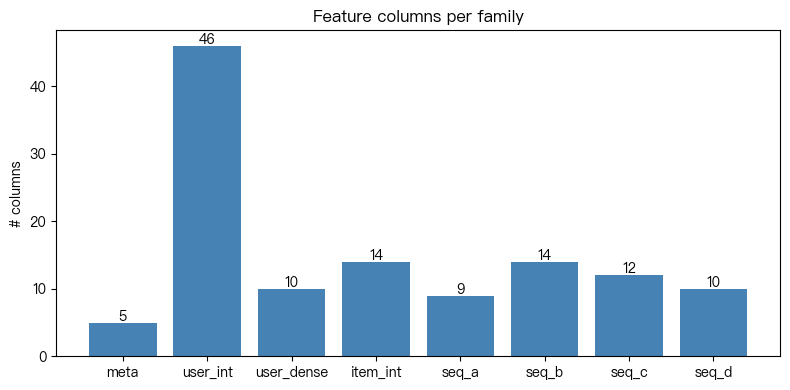

In [ ]:
# 按命名前缀切分特征族
def classify(col):
    if col in ('user_id', 'item_id', 'label_type', 'label_time', 'timestamp'):
        return 'meta'
    if col.startswith('user_int_feats_'):
        return 'user_int'
    if col.startswith('user_dense_feats_'):
        return 'user_dense'
    if col.startswith('item_int_feats_'):
        return 'item_int'
    if col.startswith('domain_a_seq_'):
        return 'seq_a'
    if col.startswith('domain_b_seq_'):
        return 'seq_b'
    if col.startswith('domain_c_seq_'):
        return 'seq_c'
    if col.startswith('domain_d_seq_'):
        return 'seq_d'
    return 'other'

groups = {}
for c in df.columns:
    groups.setdefault(classify(c), []).append(c)

for k, v in groups.items():
    print(f'{k:12s} {len(v):3d} cols')

# 可视化：每个特征族列数
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(groups.keys(), [len(v) for v in groups.values()], color='steelblue')
ax.set_ylabel('# columns')
ax.set_title('Feature columns per family')
for i, v in enumerate([len(v) for v in groups.values()]):
    ax.text(i, v + 0.3, str(v), ha='center')
plt.tight_layout()
plt.show()

Top 25 缺失率最高的列：
user_int_feats_101     0.910
user_int_feats_102     0.877
user_int_feats_103     0.862
user_int_feats_109     0.854
user_int_feats_100     0.845
item_int_feats_85      0.832
item_int_feats_84      0.832
item_int_feats_83      0.832
user_int_feats_99      0.812
user_int_feats_86      0.692
user_int_feats_96      0.678
user_int_feats_60      0.592
user_int_feats_94      0.521
user_int_feats_108     0.516
user_int_feats_92      0.494
user_int_feats_91      0.450
user_dense_feats_91    0.450
item_int_feats_11      0.439
user_int_feats_104     0.372
user_int_feats_54      0.368
user_int_feats_95      0.318
user_int_feats_105     0.309
user_int_feats_107     0.300
user_int_feats_97      0.292
user_int_feats_82      0.204
dtype: float64


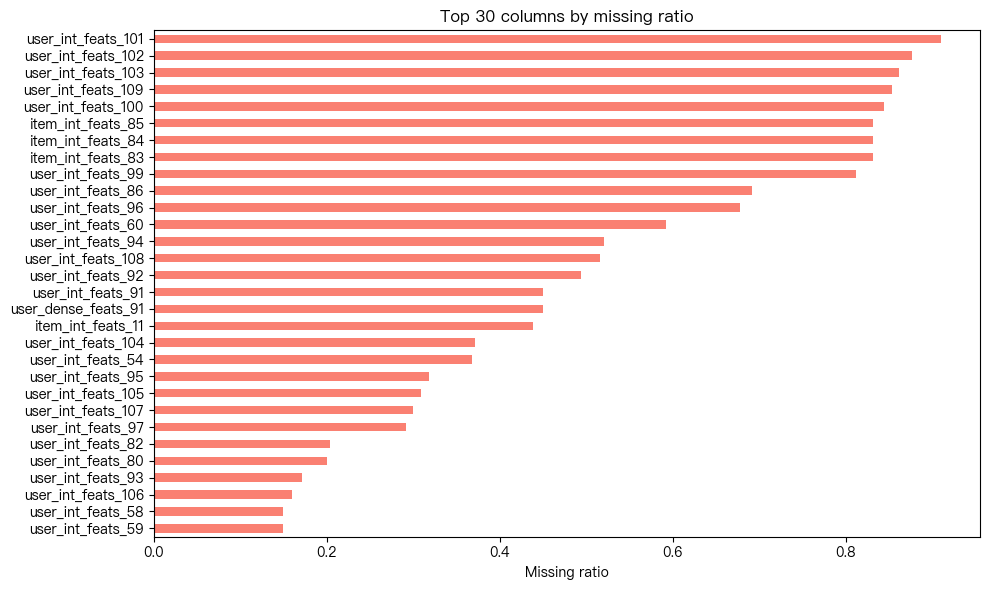

In [ ]:
# 缺失率（按特征族聚合 + Top 缺失列）
missing_ratio = df.isnull().mean().sort_values(ascending=False)
print('Top 25 缺失率最高的列：')
print(missing_ratio.head(25))

fig, ax = plt.subplots(figsize=(10, 6))
missing_ratio.head(30).plot(kind='barh', ax=ax, color='salmon')
ax.invert_yaxis()
ax.set_xlabel('Missing ratio')
ax.set_title('Top 30 columns by missing ratio')
plt.tight_layout()
plt.show()

## 2. Meta / 标签 / 时间字段

- `user_id`、`item_id`：主键。`item_id` 存在重复（837 unique / 1000 行），表明同一广告会出现在多条样本中。
- `label_type`：取值 1/2，**推测含义：转化事件类型**（如 1=浅层转化、2=深层转化），876 vs 124，正样本类型严重不均衡。
- `label_time`：发生转化的时间戳。
- `timestamp`：样本本身的时间戳（曝光/点击）。`label_time` 几乎都晚于 `timestamp`，符合转化事件的时间逻辑。

## 3. 用户离散标量特征（user_int_feats_*，标量型）

> **修订说明**：综合「基数 + 取值范围 + 分布形态 + 缺失率 + 编码连续性」重新推测含义。
> 之前把 `user_int_feats_1` 误判为性别——它取值 {1,2,4} 跳过 3，且 4 占 77.6%，更像 OS/平台。真正像性别的是 `user_int_feats_49`：二值、58:42 接近真实男女比、缺失率仅 0.7%（性别字段几乎都强制采集）。

| 字段 | unique | 取值/分布 | 重新推测 | 主要依据 |
| --- | --- | --- | --- | --- |
| `user_int_feats_1` | 3 | {1:171, 2:53, 4:776}，跳过 3 | **客户端/操作系统**（如 Android=4, iOS=1, Web=2）| 编码不连续（跳 3），4 占主导符合国内 Android 占比 |
| **`user_int_feats_49`** ⭐ | **2** | **{2:578, 1:415} ≈ 58:42** | **性别** | 二值、比例≈真实男女比、缺失率 0.7% |
| `user_int_feats_50` | 2 | {1:994, 0:2} | 是否实名/激活 | 极度倾斜，二值默认开启型字段 |
| `user_int_feats_51` | 5 | {56:995, 其他各 1} | 用户类型 (几乎常量)| 单值占 99.5% |
| `user_int_feats_55` | 13 | range 8–41 | **年龄段**（13 段）| 中等基数、有序数值跳变（8/13/14/17/19/25/29/30/34/35/37/39/41）符合年龄分桶 |
| `user_int_feats_58` | 2 | {2:594, 1:256} ≈ 70:30 | 婚姻状况 / 是否已婚 | 二值、比例符合成年用户已婚率 |
| `user_int_feats_59` | 8 | range 1–14 | **学历 / 收入档位**（8 档）| 8 档常见于学历（小/初/高/中专/专/本/硕/博）|
| `user_int_feats_82` | 23 | range 1–23 | **省级行政区编码**（23 省）| 中国大陆 23 省（不含直辖市/自治区/港澳台） |
| `user_int_feats_48` | 52 | range 3–99 | 城市等级 / 城市分档 | 52 接近 36 个地级市行政区（含直辖市）扩展或一二三四五线 + 子档 |
| `user_int_feats_52` | 36 | range 5–174 | 一级行业兴趣 / 一级类目（36 档） | 36 ≈ 行业一级分类常见数 |
| `user_int_feats_92` | 2 | **{1:253, 2:253} 完美 1:1** | 实验组 / 流量分桶 | 完美 50:50 + 缺失率 49.4%，几乎不可能是真实画像字段 |
| `user_int_feats_93` | 36 | range 1–37 | 兴趣大类 / 二级地域 | 同 52 |
| `user_int_feats_94` | 6 | range 1–6 | **消费 / 活跃等级**（6 档）| 6 档常用于 RFM/价值分层 |
| `user_int_feats_95-109` | 多 2/3 档 | 缺失率 10–91% | 一组**兴趣偏好开关 / 多任务标签**（如各品类的兴趣强度 1=低 / 2=中 / 3=高，未触达=NaN）| 取值同构、缺失率随字段递增（说明覆盖范围递减），是典型多兴趣标签组 |

下面对每个标量列绘制 **value_counts** 分布。

In [ ]:
# 区分 user_int 中的 scalar 与 list
user_int_cols = groups['user_int']
user_int_scalar = [c for c in user_int_cols if df[c].dtype != 'object']
user_int_list = [c for c in user_int_cols if df[c].dtype == 'object']
print(f'user_int 标量列 {len(user_int_scalar)} 个，多值列 {len(user_int_list)} 个')

# 标量列总览：唯一值数、非空数、min/max
rows = []
for c in user_int_scalar:
    s = df[c].dropna()
    rows.append({
        'col': c,
        'nunique': s.nunique(),
        'min': s.min(),
        'max': s.max(),
        'missing': df[c].isnull().mean(),
    })
summary = pd.DataFrame(rows).sort_values('nunique')
summary

user_int 标量列 35 个，多值列 11 个


,col,nunique,min,max,missing
17,user_int_feats_92,2,1.0,2.0,0.494
13,user_int_feats_58,2,1.0,2.0,0.150
24,user_int_feats_99,2,1.0,3.0,0.812
25,user_int_feats_100,2,1.0,2.0,0.845
26,user_int_feats_101,2,2.0,3.0,0.910
27,user_int_feats_102,2,1.0,3.0,0.877
4,user_int_feats_49,2,1.0,2.0,0.007
32,user_int_feats_107,2,1.0,2.0,0.300
5,user_int_feats_50,2,0.0,1.0,0.004
29,user_int_feats_104,3,1.0,3.0,0.372


/var/folders/k2/44nzlkx90_j4c413x3bdhd680000gn/T/ipykernel_96393/3423546334.py:54: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) PingFang HK.
  plt.tight_layout()


/Users/gaogang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) PingFang HK.
  fig.canvas.print_figure(bytes_io, **kw)


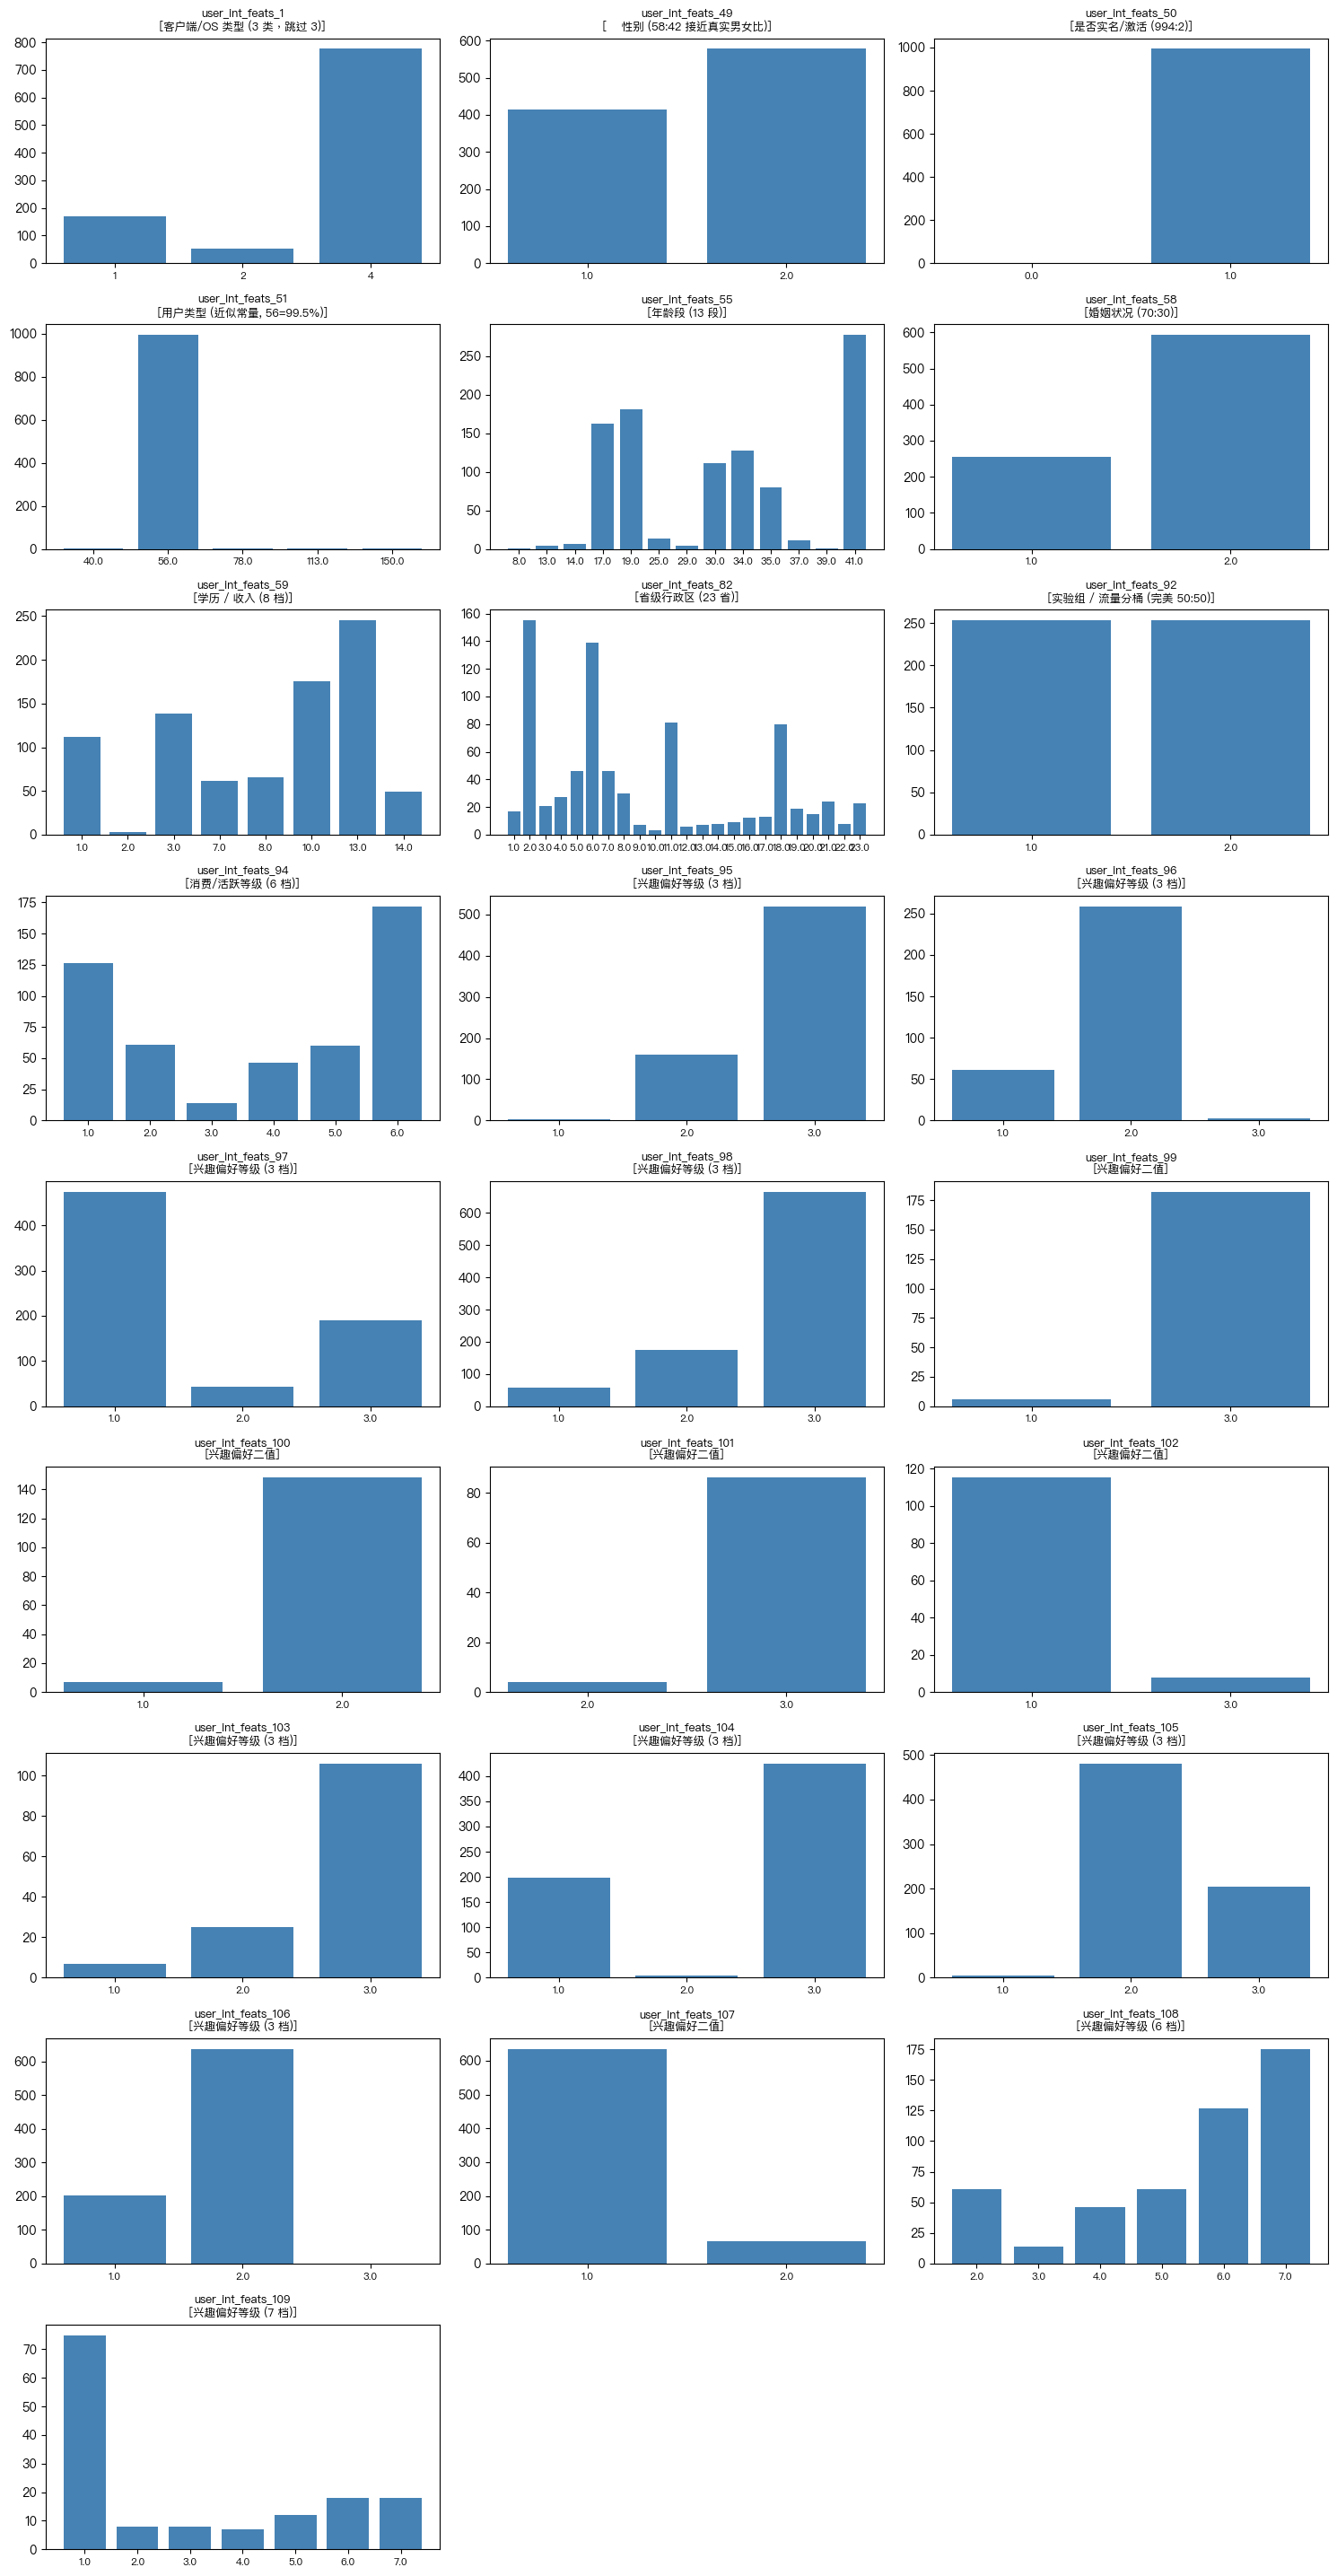

In [ ]:
# 对低基数（≤25）字段画 value_counts 柱状图，附上推测含义
# 修订版：user_int_feats_49 才是性别；user_int_feats_1 是 OS/客户端
GUESS = {
    'user_int_feats_1': '客户端/OS 类型 (3 类，跳过 3)',
    'user_int_feats_49': '⭐ 性别 (58:42 接近真实男女比)',
    'user_int_feats_50': '是否实名/激活 (994:2)',
    'user_int_feats_51': '用户类型 (近似常量, 56=99.5%)',
    'user_int_feats_55': '年龄段 (13 段)',
    'user_int_feats_58': '婚姻状况 (70:30)',
    'user_int_feats_59': '学历 / 收入 (8 档)',
    'user_int_feats_82': '省级行政区 (23 省)',
    'user_int_feats_92': '实验组 / 流量分桶 (完美 50:50)',
    'user_int_feats_94': '消费/活跃等级 (6 档)',
    'user_int_feats_95': '兴趣偏好等级 (3 档)',
    'user_int_feats_96': '兴趣偏好等级 (3 档)',
    'user_int_feats_97': '兴趣偏好等级 (3 档)',
    'user_int_feats_98': '兴趣偏好等级 (3 档)',
    'user_int_feats_99': '兴趣偏好二值',
    'user_int_feats_100': '兴趣偏好二值',
    'user_int_feats_101': '兴趣偏好二值',
    'user_int_feats_102': '兴趣偏好二值',
    'user_int_feats_103': '兴趣偏好等级 (3 档)',
    'user_int_feats_104': '兴趣偏好等级 (3 档)',
    'user_int_feats_105': '兴趣偏好等级 (3 档)',
    'user_int_feats_106': '兴趣偏好等级 (3 档)',
    'user_int_feats_107': '兴趣偏好二值',
    'user_int_feats_108': '兴趣偏好等级 (6 档)',
    'user_int_feats_109': '兴趣偏好等级 (7 档)',
    'user_int_feats_48': '城市等级 / 城市分档 (52)',
    'user_int_feats_52': '一级行业兴趣 (36 档)',
    'user_int_feats_93': '兴趣大类 / 二级地域 (36 档)',
}

low_card = [c for c in user_int_scalar if df[c].nunique() <= 25]
n = len(low_card)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.2 * nrows))
axes = np.atleast_2d(axes).reshape(nrows, ncols)

for idx, c in enumerate(low_card):
    ax = axes[idx // ncols][idx % ncols]
    vc = df[c].value_counts().sort_index()
    ax.bar(vc.index.astype(str), vc.values, color='steelblue')
    title = c
    if c in GUESS:
        title += f'\n[{GUESS[c]}]'
    ax.set_title(title, fontsize=9)
    ax.tick_params(axis='x', labelsize=8)

for idx in range(n, nrows * ncols):
    axes[idx // ncols][idx % ncols].axis('off')

plt.tight_layout()
plt.show()

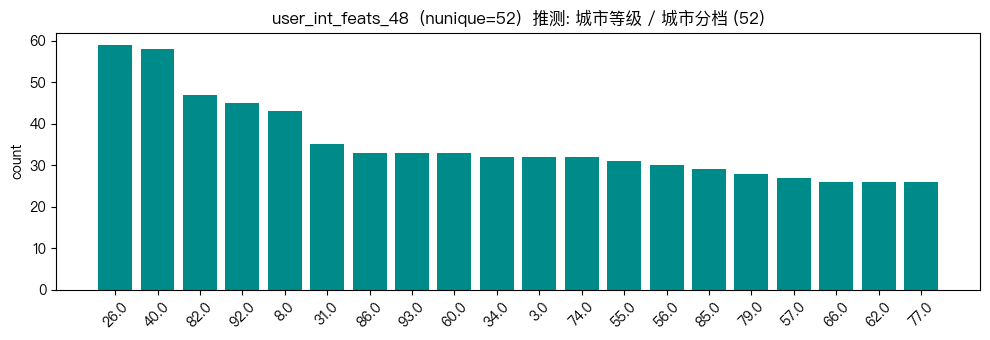

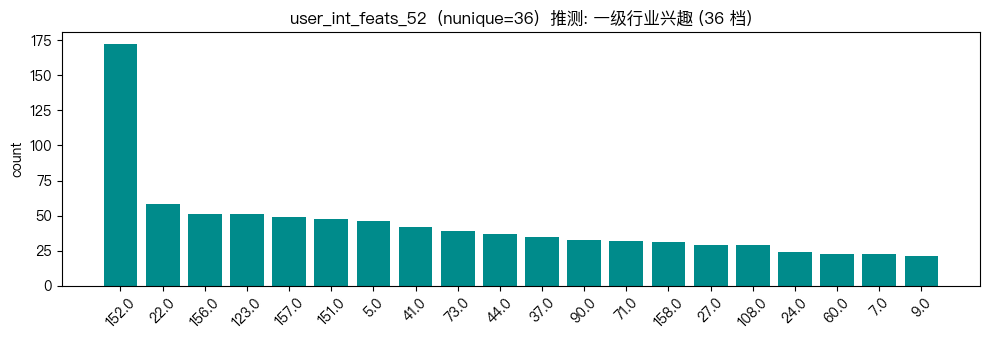

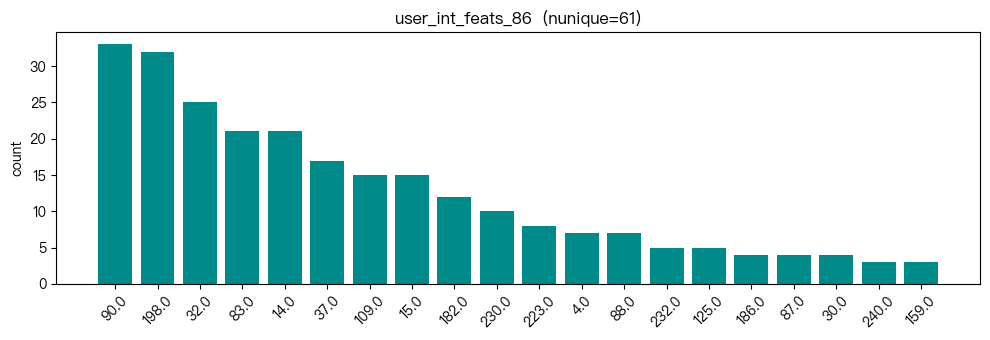

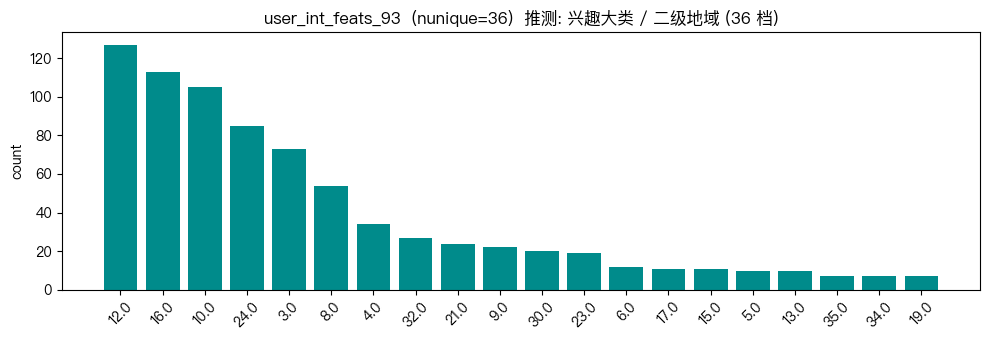

In [ ]:
# 中等基数（26-100，可能是省份 / 城市 / 行业等）：top-20 value_counts
mid_card = [c for c in user_int_scalar if 25 < df[c].nunique() <= 100]
TOP_K = 20
for c in mid_card:
    fig, ax = plt.subplots(figsize=(10, 3.5))
    vc = df[c].value_counts().head(TOP_K)
    ax.bar(vc.index.astype(str), vc.values, color='darkcyan')
    title = f'{c}  (nunique={df[c].nunique()})'
    if c in GUESS:
        title += f'  推测: {GUESS[c]}'
    ax.set_title(title)
    ax.set_ylabel('count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

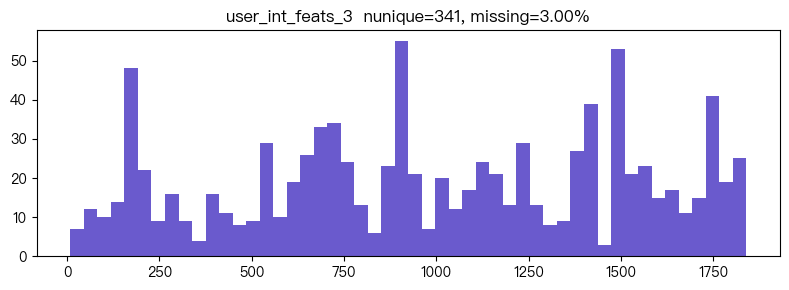

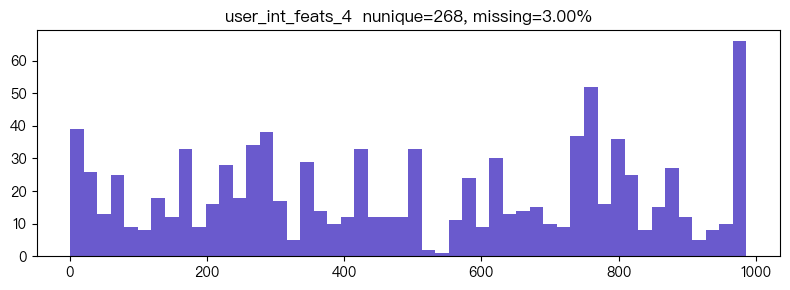

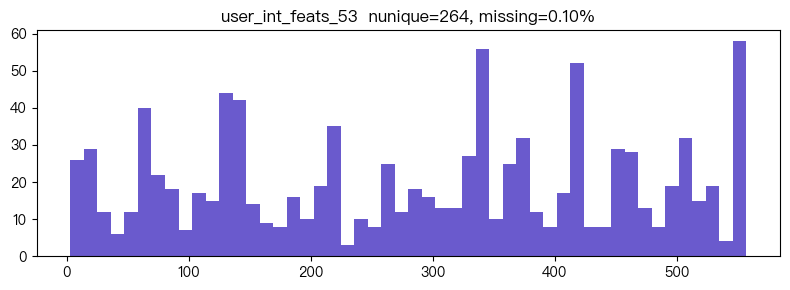

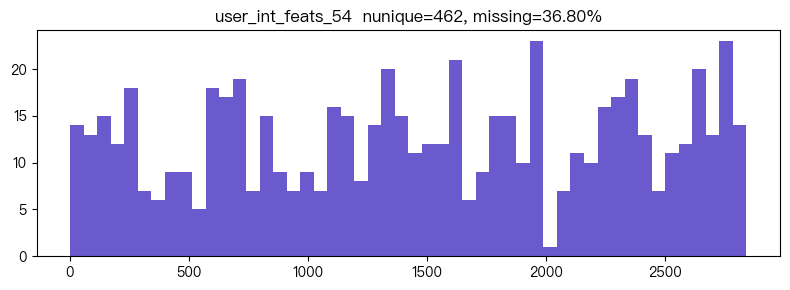

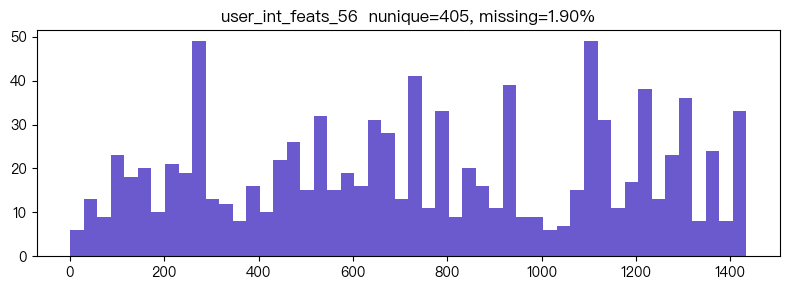

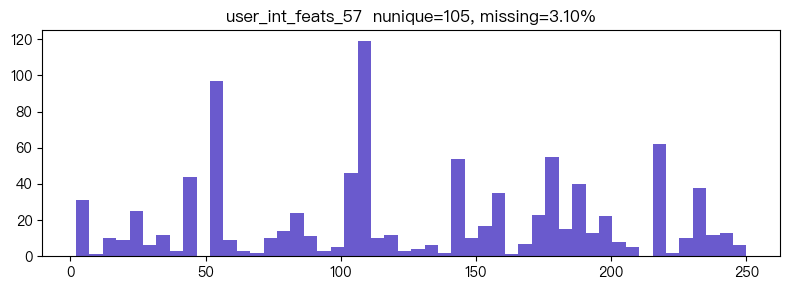

In [ ]:
# 高基数（>100，连续型 / ID 型）：直方图
high_card = [c for c in user_int_scalar if df[c].nunique() > 100]
for c in high_card:
    fig, ax = plt.subplots(figsize=(8, 3))
    s = df[c].dropna()
    ax.hist(s, bins=50, color='slateblue')
    ax.set_title(f'{c}  nunique={df[c].nunique()}, missing={df[c].isnull().mean():.2%}')
    plt.tight_layout()
    plt.show()

## 4. 用户离散多值特征（user_int list 列）

这些字段的每个 cell 是一个 list，长度可变，常见用作：

- 兴趣 tag 集合
- 历史浏览品类
- 多选偏好
- 关注的标签 ID

下面对每个 list 列分别画：（a）list 长度分布；（b）value_counts 取 top 20。

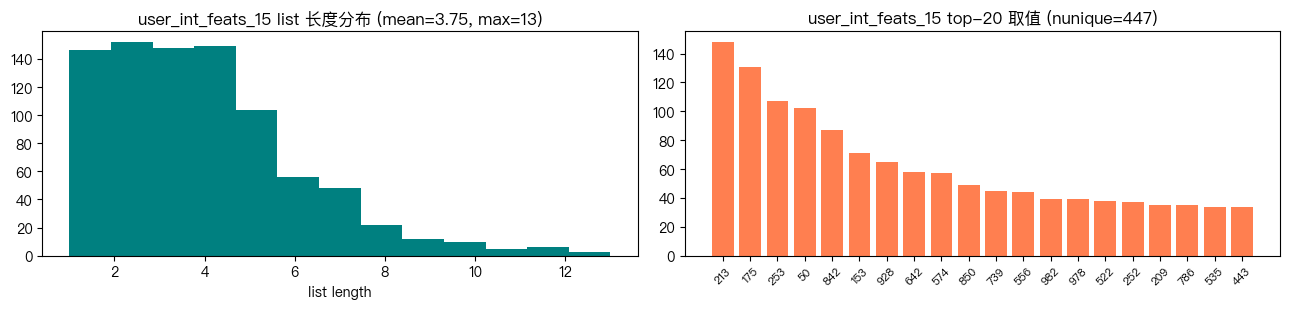

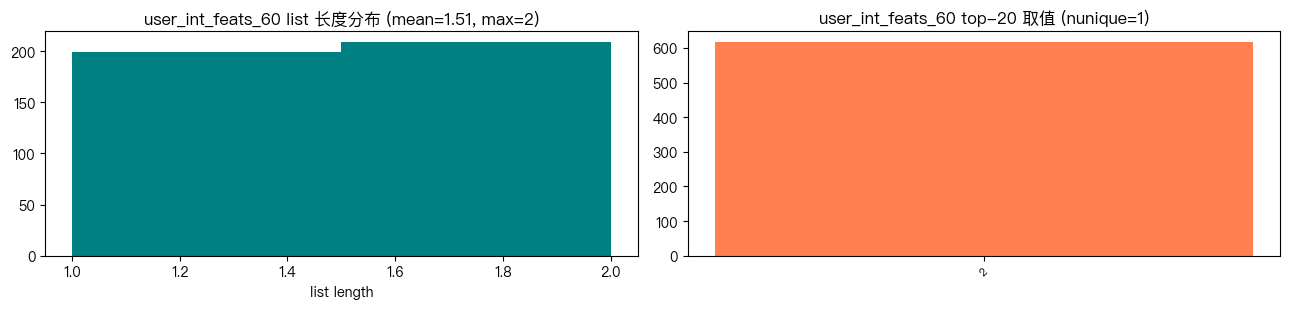

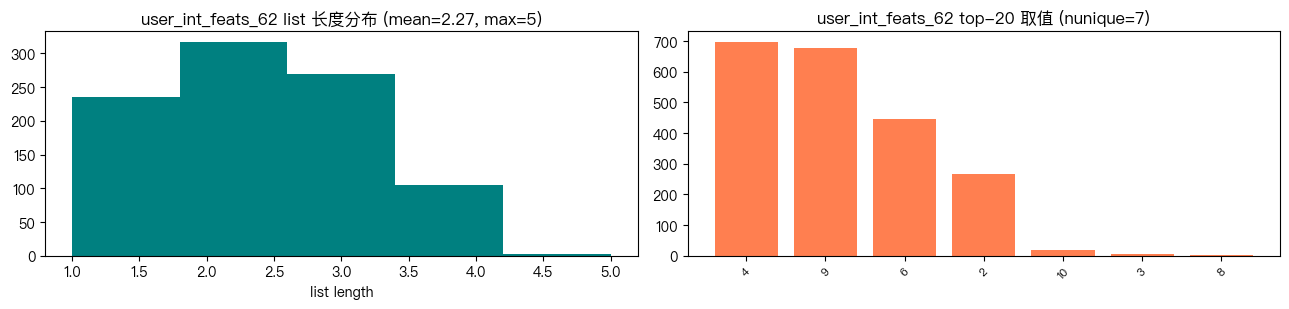

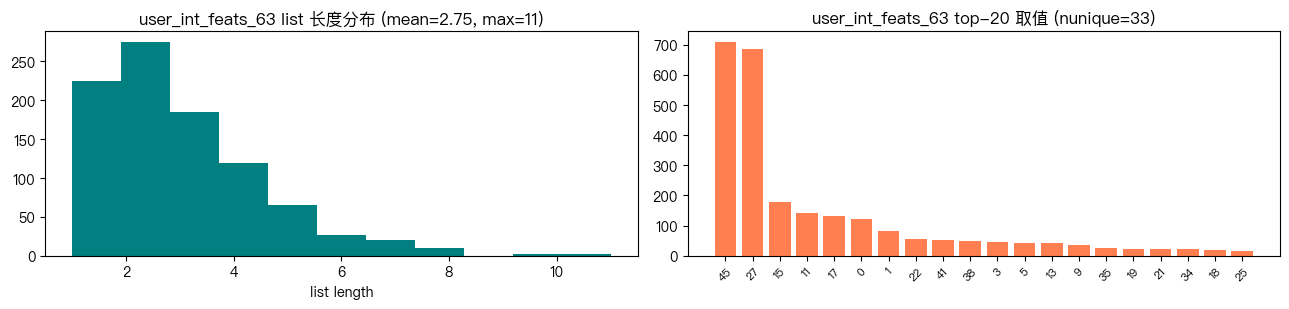

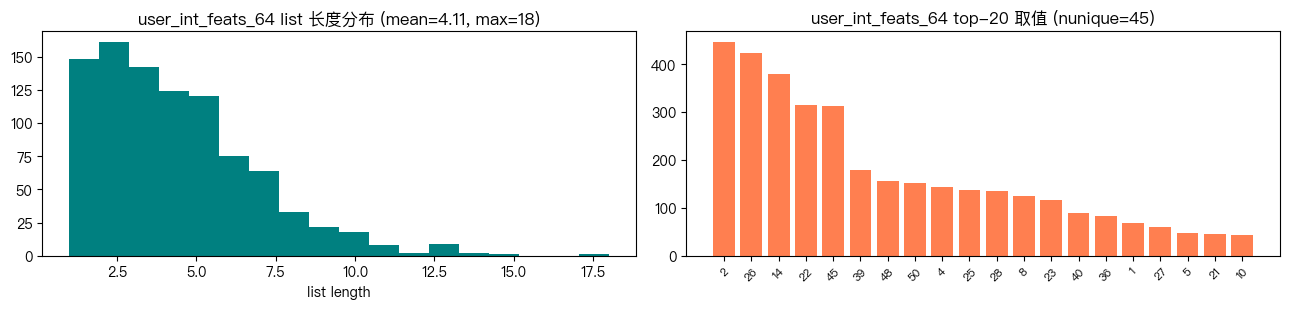

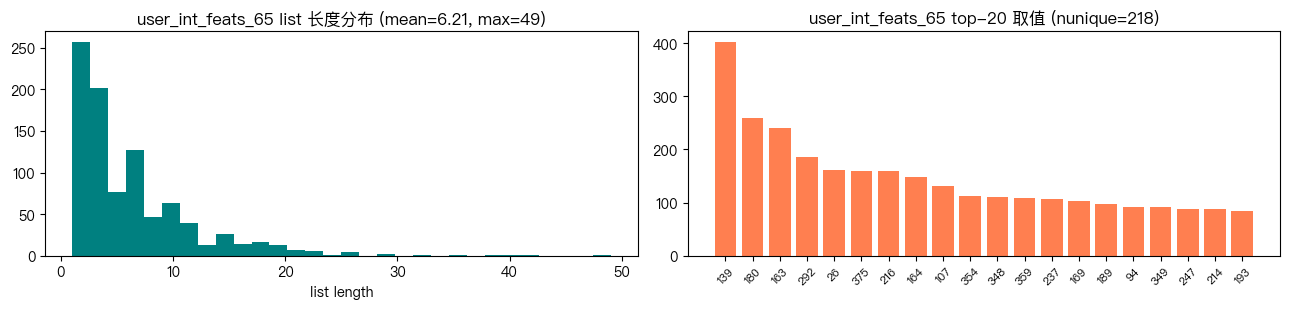

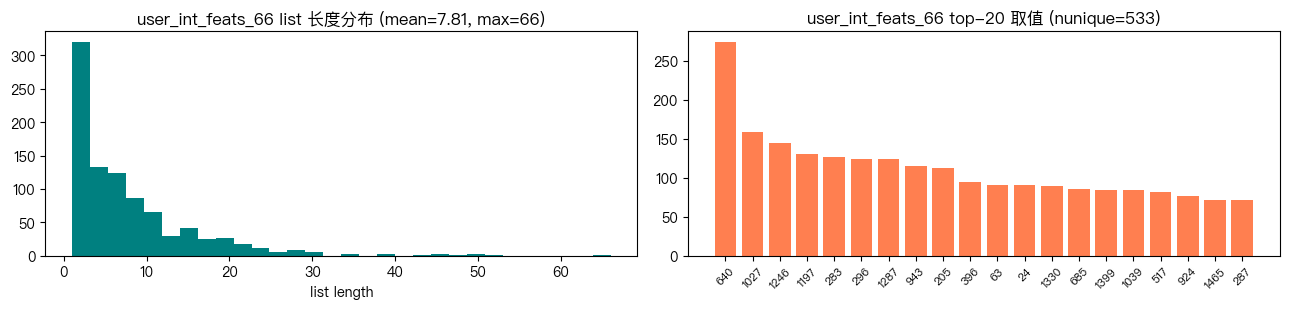

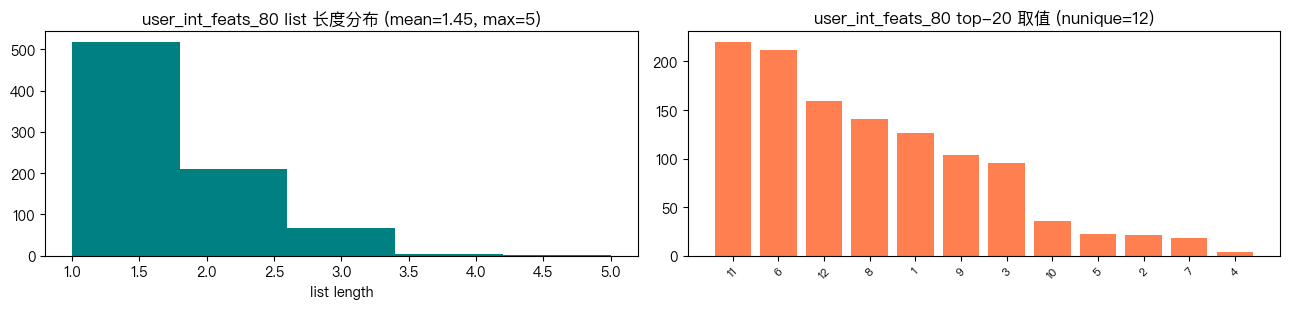

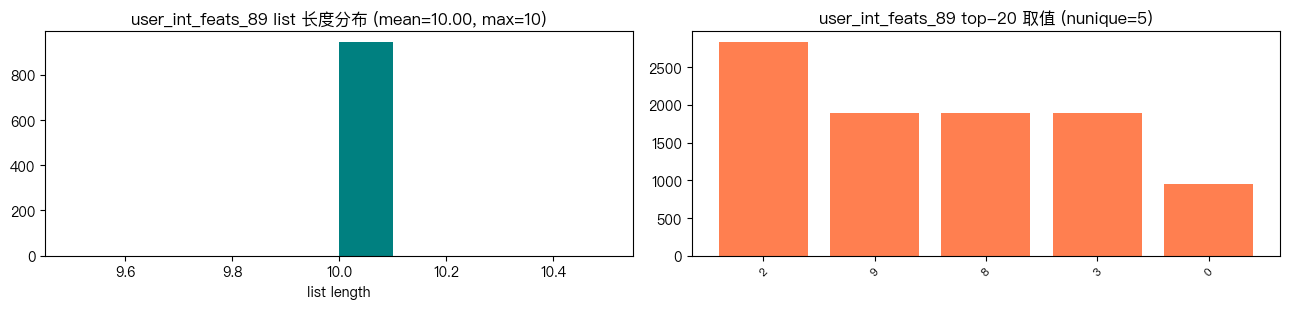

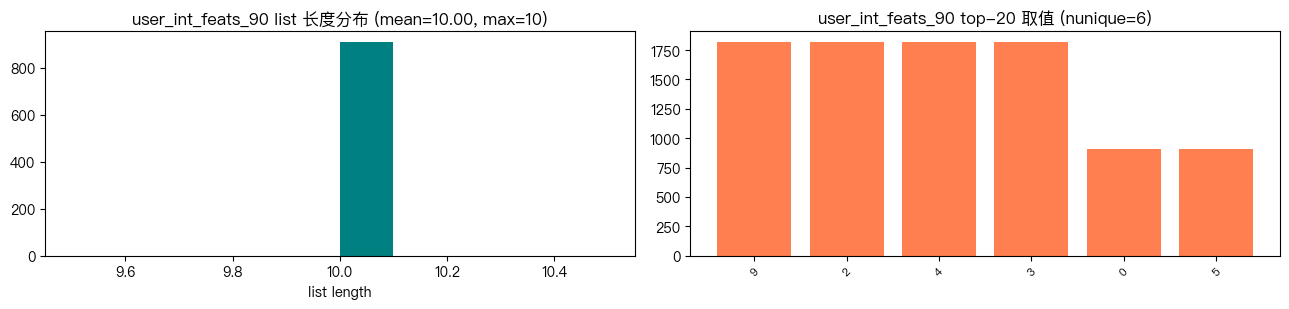

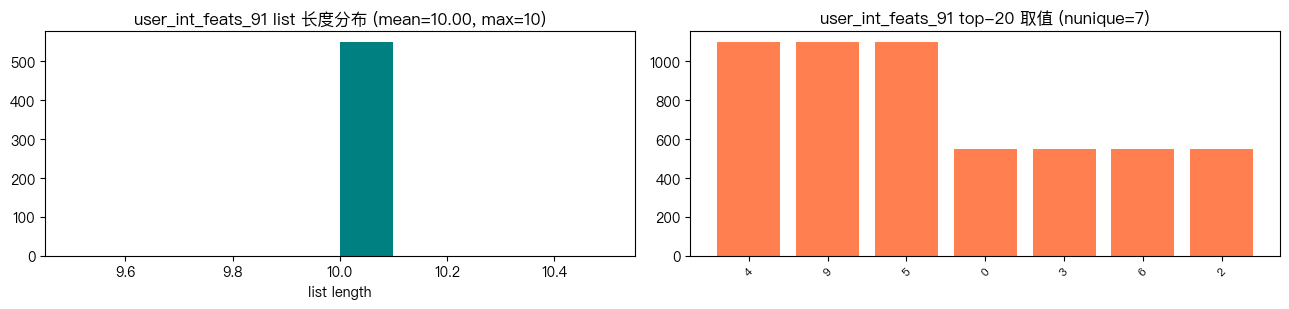

In [ ]:
def explode_list_col(series):
    out = []
    for v in series.dropna():
        if hasattr(v, '__iter__'):
            out.extend(list(v))
    return np.array(out)

for c in user_int_list:
    s = df[c].dropna()
    if len(s) == 0:
        continue
    lens = s.apply(lambda x: len(x) if hasattr(x, '__len__') else 0)
    flat = explode_list_col(s)

    fig, axes = plt.subplots(1, 2, figsize=(13, 3.2))
    axes[0].hist(lens, bins=min(30, lens.max()), color='teal')
    axes[0].set_title(f'{c} list 长度分布 (mean={lens.mean():.2f}, max={lens.max()})')
    axes[0].set_xlabel('list length')

    if len(flat) > 0:
        vc = pd.Series(flat).value_counts().head(20)
        axes[1].bar(vc.index.astype(str), vc.values, color='coral')
        axes[1].set_title(f'{c} top-20 取值 (nunique={pd.Series(flat).nunique()})')
        axes[1].tick_params(axis='x', rotation=45, labelsize=8)
    plt.tight_layout()
    plt.show()

## 5. 用户 dense 特征（user_dense_feats_*）— 深度推测

> 综合「向量长度 + L2 范数 + 稀疏度 + 与 user_int list 的对齐关系 + 字段间相关性」做精细推断。`ns_groups.json` 注明 fid 62-66 / 89-91 的 int 与 dense 部分 **逐元素对齐**——这是关键先验。

### 5.1 三类 dense 特征

| 字段 | 维度 | L2 范数 | 0 元素比 | 与 int 对齐 | **修订推测** |
| --- | --- | --- | --- | --- | --- |
| `user_dense_feats_61` | **固定 256** | **0.997 ± 0.004**（严格归一化）| 0% | 无 | **L2 归一化的用户预训练向量**（如双塔召回模型的 user tower 输出 / U2I 表征）|
| `user_dense_feats_87` | **固定 320** | **1.875 ± 0.587**（差异大）| **61.3%** | 无 | **稀疏多兴趣胶囊向量**（如 MIND/ComiRec 多兴趣，每个胶囊 ≈ 一个兴趣方向，未激活胶囊为零）。L2 变化大反映用户兴趣集中度差异 |
| `user_dense_feats_89/90/91` | **固定 10** | **1.000 ± 0.000**（严格单位向量）| ~0% | 与 `user_int_feats_89/90/91` 同位对齐（int 是 top-10 兴趣 ID）| **同一组 top-10 兴趣在不同时间窗下的归一化偏好分布**。三组互相同行余弦：89 vs 90 = **0.997**（几乎相同，相邻窗口）；89 vs 91 = **0.789**（明显差异，长短窗对比）|
| `user_dense_feats_62-66` | **变长**（max 5/11/18/49/66）| 数值大（41 ~ 1.8e7）| 无 | 与 `user_int_feats_62-66` 同位对齐 | **层级品类的累计行为统计**（如曝光/点击/时长）。62→66 五级粒度由粗到细，同一行为在层级间共享 dense 数值 |

### 5.2 几个关键发现

**(A) `dense_61` 是 L2 归一化的稠密预训练向量**
- L2 范数严格 ≈ 1（std 仅 0.004）
- 0 元素比例 0%，逐维近似高斯分布
- 256 维是 BERT-base / sentence-transformer / 双塔召回的标准 user-tower 维度
- 适合作为 backbone 的固定 embedding 输入或与可训练 ID embedding 拼接

**(B) `dense_87` 是稀疏多兴趣表征**
- 61.3% 元素为 0，25%/50%/75% 分位数都是 0
- L2 范数 1.88 ± 0.59 变化大 → 用户兴趣集中度差异
- 320 = 32×10 或 16×20，常见于多兴趣胶囊网络（MIND）
- 与 `dense_61` 互补：61 是稠密表征，87 是稀疏多兴趣分支

**(C) `dense_89/90/91` 是不同时间窗下的兴趣偏好分布**
- 三组 `int_89/90/91` 的 top-10 兴趣 ID **完全相同**，但 dense 值不同
- 89↔90 余弦 0.997（极高，相邻窗口）；89↔91 余弦 0.789（中等，长短窗）
- 缺失率递增（5.5% → 9.1% → 45.0%）→ **窗口越长越容易缺失**（如近 7 天 → 30 天 → 90 天）
- std = 0.3162 ≈ 1/√10，正好是 10 维单位向量在每个分量上的理论标准差，说明是数学上严格归一化的偏好分布

**(D) `dense_62-66` 是层级品类的累计行为统计**
- 长度递增：max 5（一级）→ 11（二级）→ 18（三级）→ 49（四级）→ 66（五级）
- 同一用户在同一行为下，dense 数值在层级间会重复出现（叶子聚合到根的层级特征）
- 量级 1e2 ~ 1e7 → 暗示是累计曝光数 / 点击数 / 停留时长
- 与 int 长度严格相等（930 / 920 / 914 行验证通过）

### 5.3 建模建议

1. `dense_61` 直接作为 NS token 的 base 向量（已在 baseline 中）；
2. `dense_87` 因高度稀疏，建议先用 `mask = (x != 0)` 提取激活通道索引再 embed，避免对零向量做 LayerNorm；
3. `dense_89/90/91` + `int_89/90/91` 是天然的 **(ID, 权重)** 对，应做 weighted-sum-pooling 或 attention pooling，而不是 mean pooling；
4. `dense_62-66` 是层级聚合，可对每个层级做 log1p 变换后再用 weighted-sum 与对应 int ID 拼接。"

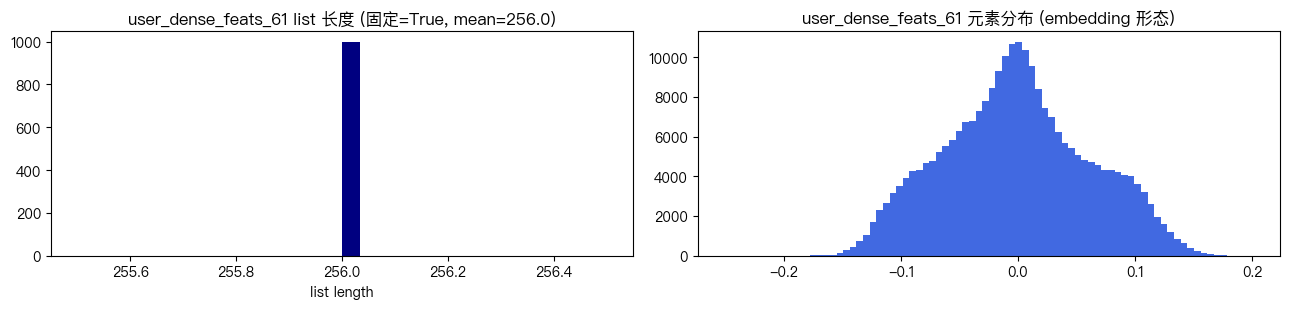

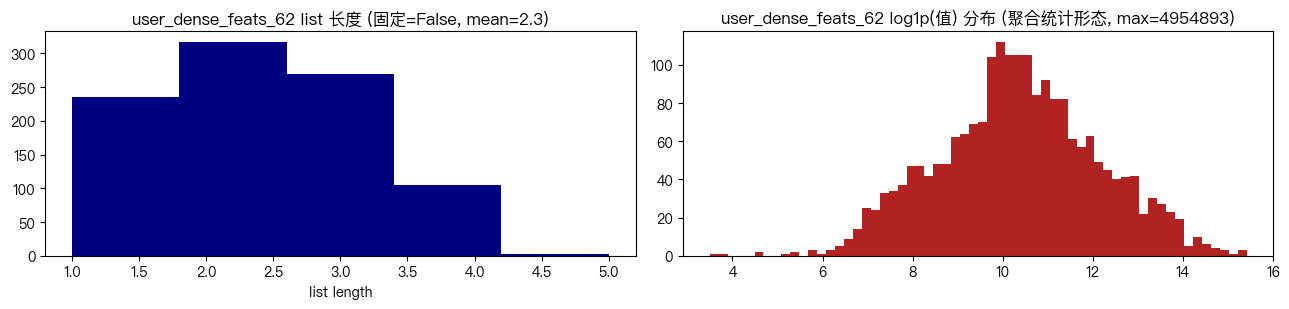

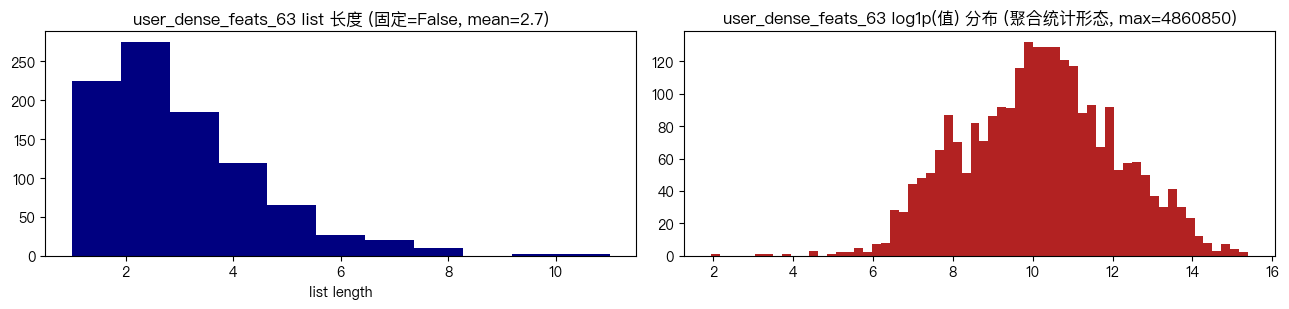

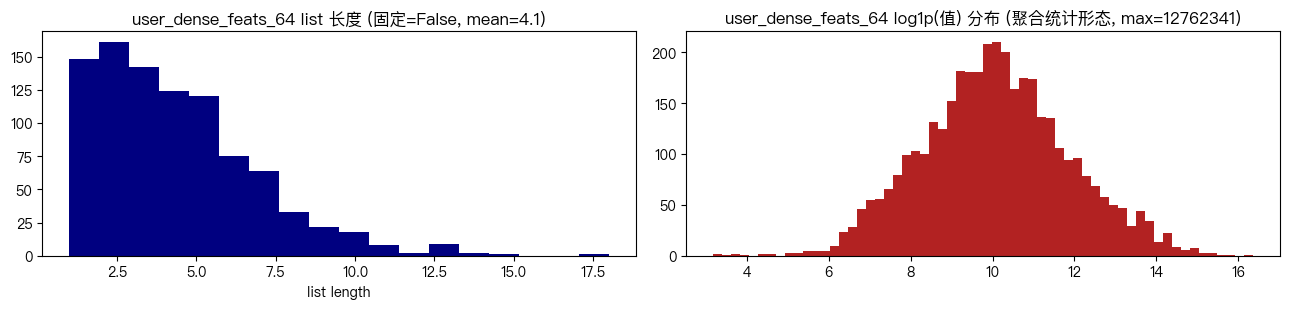

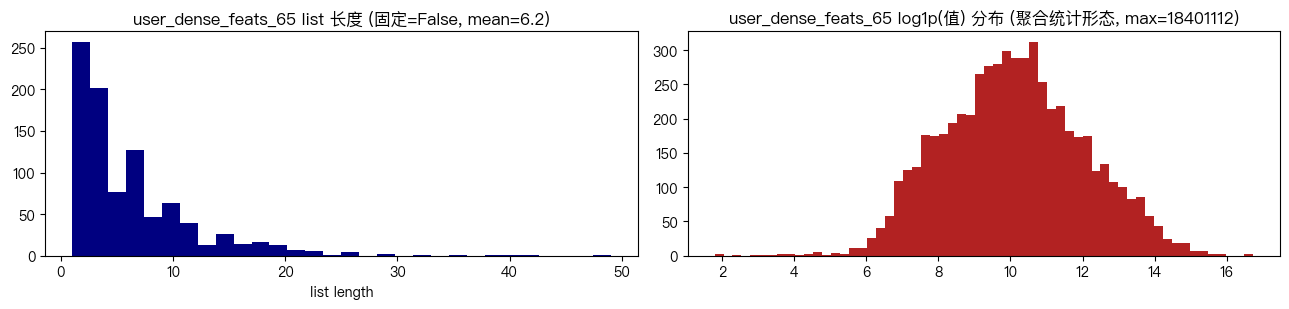

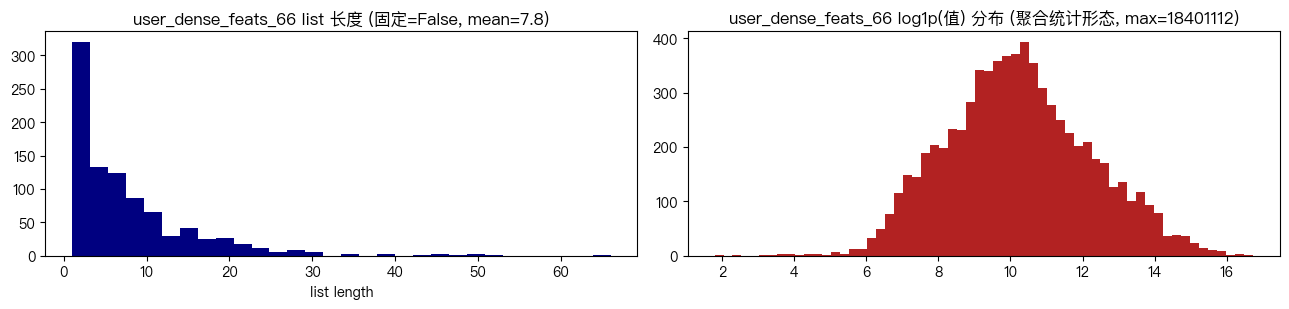

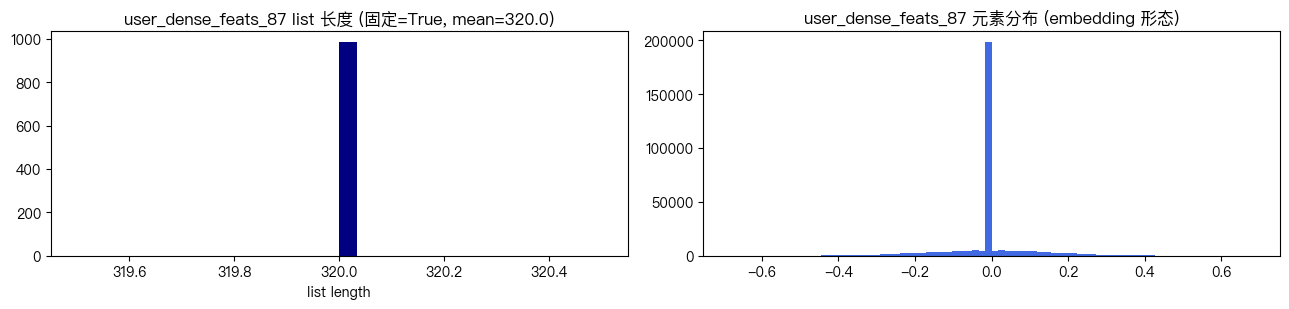

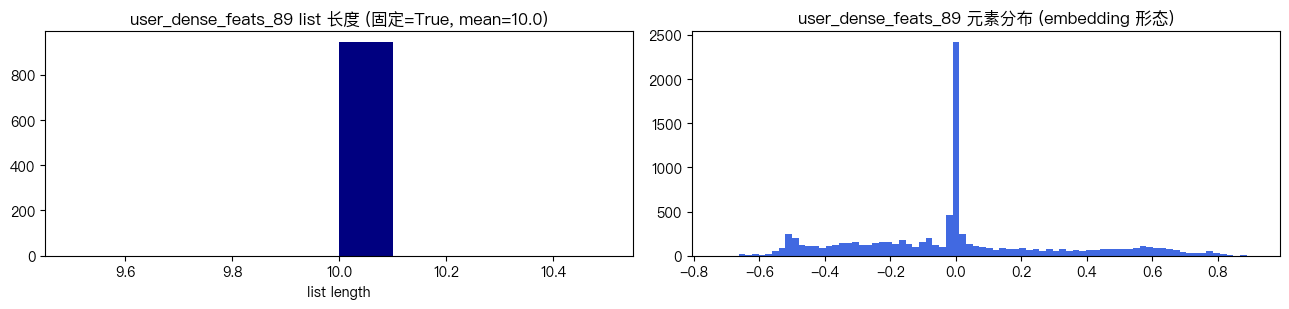

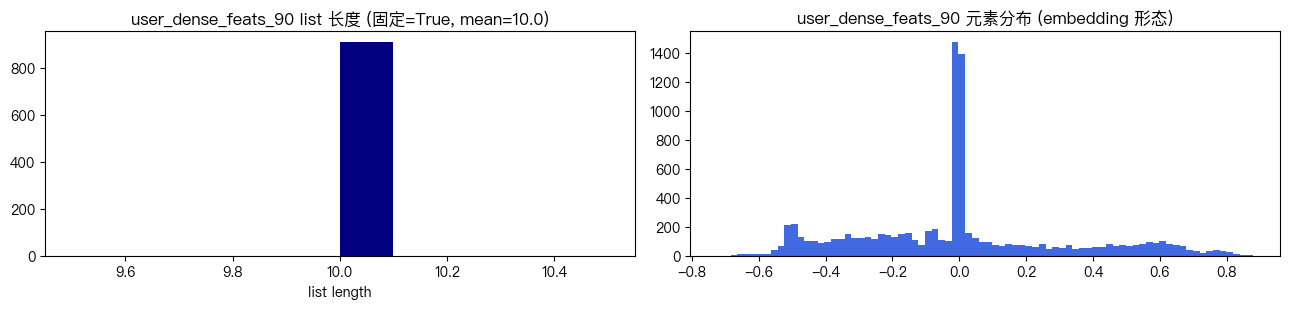

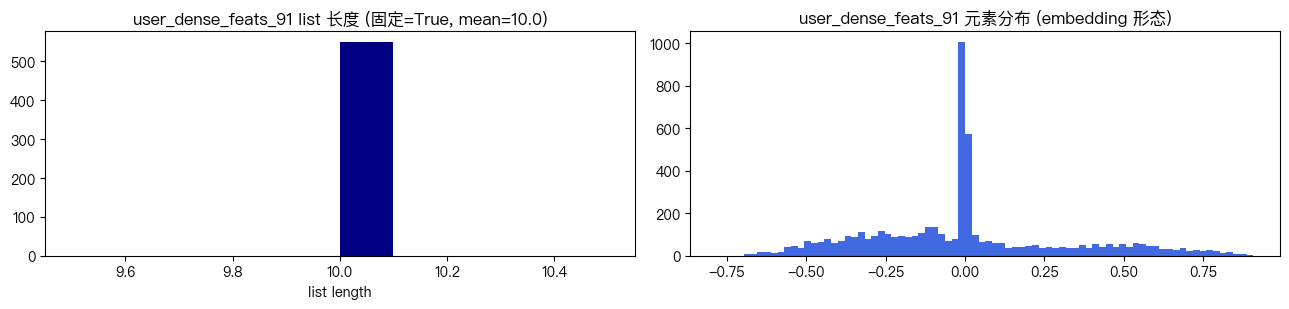


数学验证：L2 范数 + 零元素比例 (定长 dense)
                col  dim  L2_mean   L2_std  zero_ratio
user_dense_feats_61  256 0.997760 0.002497    0.000000
user_dense_feats_87  320 1.889294 0.544581    0.613469
user_dense_feats_89   10 1.000000 0.000028    0.002800
user_dense_feats_90   10 1.000000 0.000028    0.003200
user_dense_feats_91   10 0.999999 0.000030    0.001200


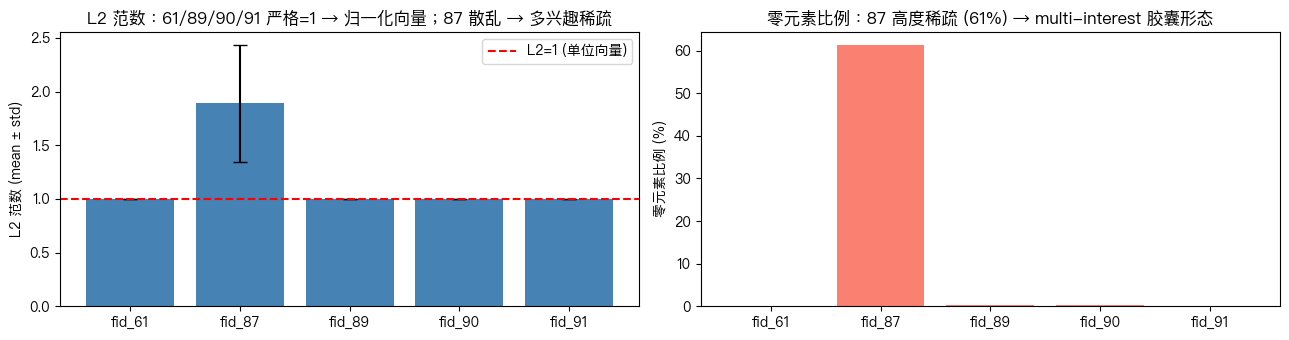


89/90/91 三组同行余弦：验证「不同时间窗」假设


/var/folders/k2/44nzlkx90_j4c413x3bdhd680000gn/T/ipykernel_96393/3309657657.py:96: UserWarning: Glyph 8596 (\N{LEFT RIGHT ARROW}) missing from font(s) PingFang HK.
  plt.tight_layout()
/Users/gaogang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8596 (\N{LEFT RIGHT ARROW}) missing from font(s) PingFang HK.
  fig.canvas.print_figure(bytes_io, **kw)


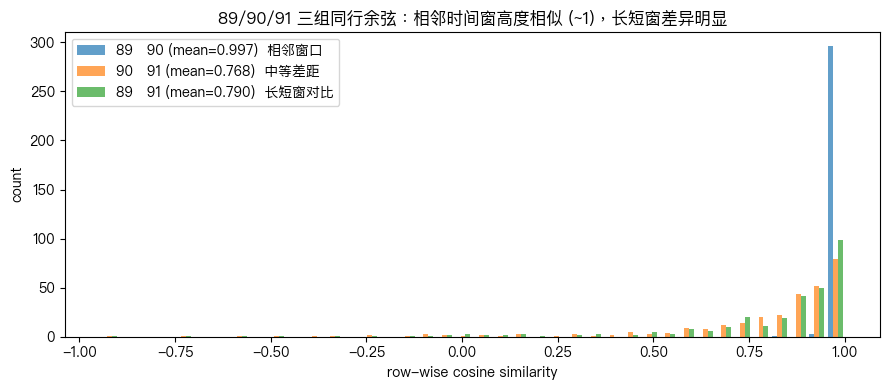


62-66 长度逐级增加：层级品类的证据


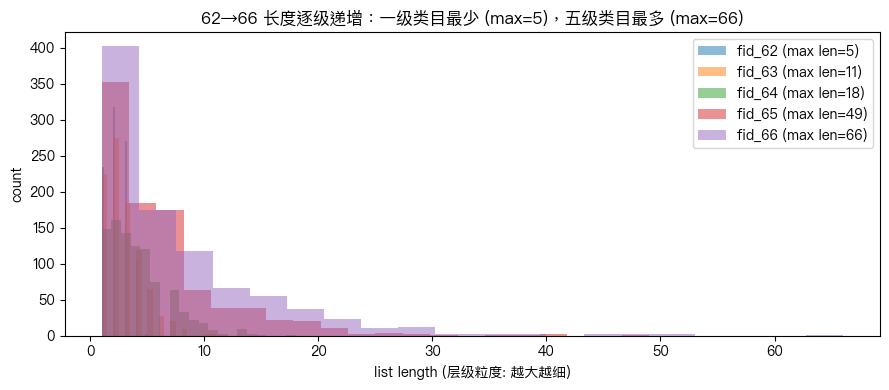


int-dense 对齐验证：长度严格相等
 fid  samples  all_aligned
  62      930         True
  63      930         True
  64      930         True
  65      920         True
  66      914         True
  89      945         True
  90      909         True
  91      550         True


In [ ]:
user_dense_cols = groups['user_dense']

# ----- (1) 基础分布：长度 / 元素值 -----
for c in user_dense_cols:
    s = df[c].dropna()
    if len(s) == 0:
        continue
    lens = s.apply(lambda x: len(x) if hasattr(x, '__len__') else 0)
    flat = explode_list_col(s)

    fig, axes = plt.subplots(1, 2, figsize=(13, 3.2))
    axes[0].hist(lens, bins=min(30, max(lens.max(), 1)), color='navy')
    axes[0].set_title(f'{c} list 长度 (固定={lens.min()==lens.max()}, mean={lens.mean():.1f})')
    axes[0].set_xlabel('list length')

    if len(flat) > 0:
        if abs(flat.max()) < 5 and abs(flat.min()) < 5:
            axes[1].hist(flat, bins=80, color='royalblue')
            axes[1].set_title(f'{c} 元素分布 (embedding 形态)')
        else:
            pos = flat[flat > 0]
            if len(pos) > 0:
                axes[1].hist(np.log1p(pos), bins=60, color='firebrick')
                axes[1].set_title(f'{c} log1p(值) 分布 (聚合统计形态, max={flat.max():.0f})')
    plt.tight_layout()
    plt.show()

# ----- (2) 数学验证：L2 范数 / 稀疏度 -----
print('\n' + '=' * 70)
print('数学验证：L2 范数 + 零元素比例 (定长 dense)')
print('=' * 70)
fixed_dense = ['user_dense_feats_61', 'user_dense_feats_87',
               'user_dense_feats_89', 'user_dense_feats_90', 'user_dense_feats_91']
metrics = []
for c in fixed_dense:
    s = df[c].dropna()
    norms = []
    zero_ratios = []
    for v in s.head(500):
        a = np.array(list(v), dtype=np.float64)
        norms.append(np.linalg.norm(a))
        zero_ratios.append((a == 0).mean())
    metrics.append({'col': c, 'dim': len(s.iloc[0]),
                    'L2_mean': np.mean(norms), 'L2_std': np.std(norms),
                    'zero_ratio': np.mean(zero_ratios)})
mt = pd.DataFrame(metrics)
print(mt.to_string(index=False))

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
axes[0].bar(mt['col'].apply(lambda x: x.replace('user_dense_feats_', 'fid_')),
            mt['L2_mean'], yerr=mt['L2_std'], color='steelblue', capsize=5)
axes[0].axhline(1.0, color='red', linestyle='--', label='L2=1 (单位向量)')
axes[0].set_ylabel('L2 范数 (mean ± std)')
axes[0].set_title('L2 范数：61/89/90/91 严格=1 → 归一化向量；87 散乱 → 多兴趣稀疏')
axes[0].legend()

axes[1].bar(mt['col'].apply(lambda x: x.replace('user_dense_feats_', 'fid_')),
            mt['zero_ratio'] * 100, color='salmon')
axes[1].set_ylabel('零元素比例 (%)')
axes[1].set_title('零元素比例：87 高度稀疏 (61%) → multi-interest 胶囊形态')
plt.tight_layout()
plt.show()

# ----- (3) 89/90/91 三组同行余弦：验证"不同时间窗"假设 -----
print('\n' + '=' * 70)
print('89/90/91 三组同行余弦：验证「不同时间窗」假设')
print('=' * 70)
common_idx = df[
    df['user_dense_feats_89'].notna() &
    df['user_dense_feats_90'].notna() &
    df['user_dense_feats_91'].notna()
].head(300).index
m = {fid: np.stack([np.array(df.loc[i, f'user_dense_feats_{fid}']) for i in common_idx])
     for fid in [89, 90, 91]}

def row_cos(A, B):
    A = A / (np.linalg.norm(A, axis=1, keepdims=True) + 1e-9)
    B = B / (np.linalg.norm(B, axis=1, keepdims=True) + 1e-9)
    return (A * B).sum(axis=1)

c8990 = row_cos(m[89], m[90])
c8991 = row_cos(m[89], m[91])
c9091 = row_cos(m[90], m[91])

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist([c8990, c9091, c8991], bins=40, label=[
    f'89↔90 (mean={c8990.mean():.3f})  相邻窗口',
    f'90↔91 (mean={c9091.mean():.3f})  中等差距',
    f'89↔91 (mean={c8991.mean():.3f})  长短窗对比',
], stacked=False, alpha=0.7)
ax.set_xlabel('row-wise cosine similarity')
ax.set_ylabel('count')
ax.set_title('89/90/91 三组同行余弦：相邻时间窗高度相似 (~1)，长短窗差异明显')
ax.legend()
plt.tight_layout()
plt.show()

# ----- (4) 62-66 长度逐级增加 → 层级品类 -----
print('\n' + '=' * 70)
print('62-66 长度逐级增加：层级品类的证据')
print('=' * 70)
fig, ax = plt.subplots(figsize=(9, 4))
for fid in [62, 63, 64, 65, 66]:
    s = df[f'user_dense_feats_{fid}'].dropna()
    lens = s.apply(len)
    ax.hist(lens, bins=20, alpha=0.5, label=f'fid_{fid} (max len={lens.max()})')
ax.set_xlabel('list length (层级粒度: 越大越细)')
ax.set_ylabel('count')
ax.set_title('62→66 长度逐级递增：一级类目最少 (max=5)，五级类目最多 (max=66)')
ax.legend()
plt.tight_layout()
plt.show()

# ----- (5) int-dense 对齐验证 -----
print('\n' + '=' * 70)
print('int-dense 对齐验证：长度严格相等')
print('=' * 70)
align_rows = []
for fid in [62, 63, 64, 65, 66, 89, 90, 91]:
    icol = f'user_int_feats_{fid}'
    dcol = f'user_dense_feats_{fid}'
    if icol not in df.columns or dcol not in df.columns:
        continue
    sub = df[df[icol].notna() & df[dcol].notna()]
    aligned = sub.apply(lambda r: len(r[icol]) == len(r[dcol]), axis=1).all()
    align_rows.append({'fid': fid, 'samples': len(sub), 'all_aligned': aligned})
print(pd.DataFrame(align_rows).to_string(index=False))

## 6. 物料离散特征（item_int_feats_*）

根据基数推测：

| 字段 | nunique | 推测含义 |
| --- | --- | --- |
| `item_int_feats_13` | 8 | **广告/创意类型**（图文 / 视频 / 横幅 …）|
| `item_int_feats_81` | 3 | 投放渠道（3 档） |
| `item_int_feats_9` | 24 | **一级行业类目** |
| `item_int_feats_83` | 22 | 二级行业 / 投放属性 |
| `item_int_feats_5` | 82 | **三级品类** 或 广告主类型 |
| `item_int_feats_84` | 66 | 行业子类 |
| `item_int_feats_10` | 110 | 创意标签 |
| `item_int_feats_85` | 103 | 广告主分组 |
| `item_int_feats_6` | 216 | 高基数行业细类 |
| `item_int_feats_7/8/12` | 200+ | 估计为 计数/排名 类离散桶 |
| `item_int_feats_16` | 662 | 物料子 ID（高基数） |
| `item_int_feats_11` | list | **物料标签集合**（多值） |

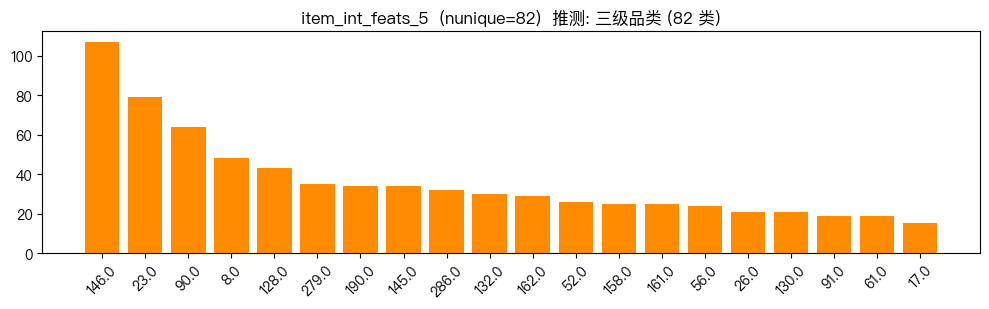

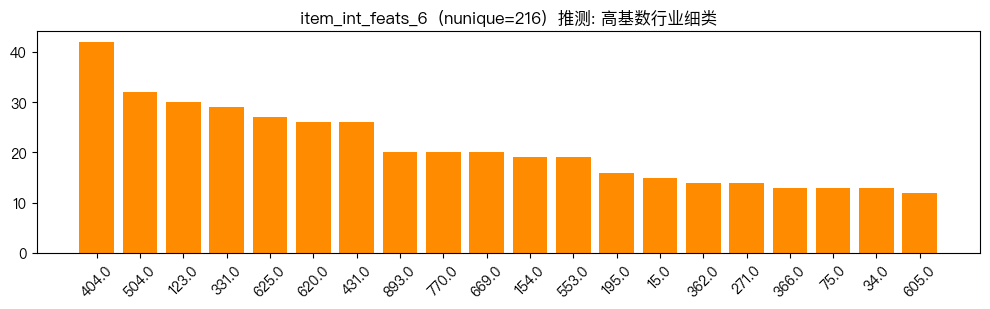

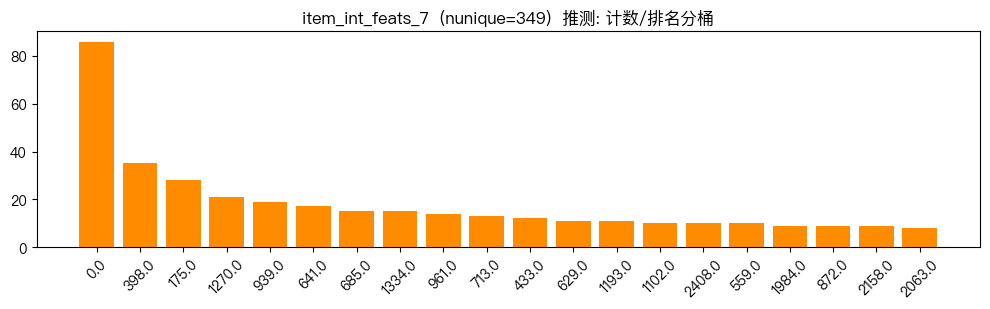

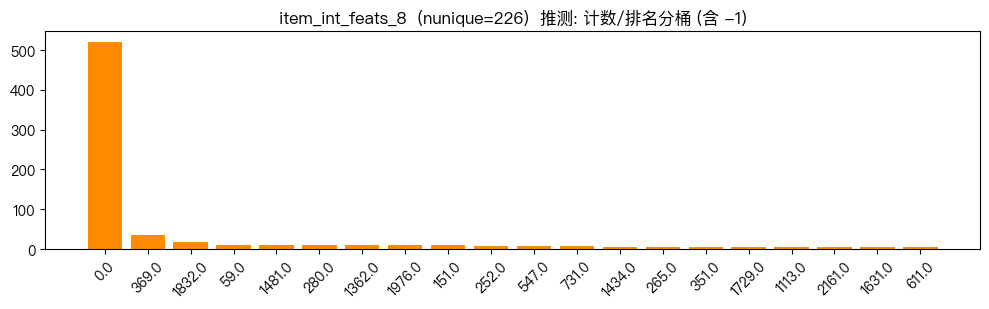

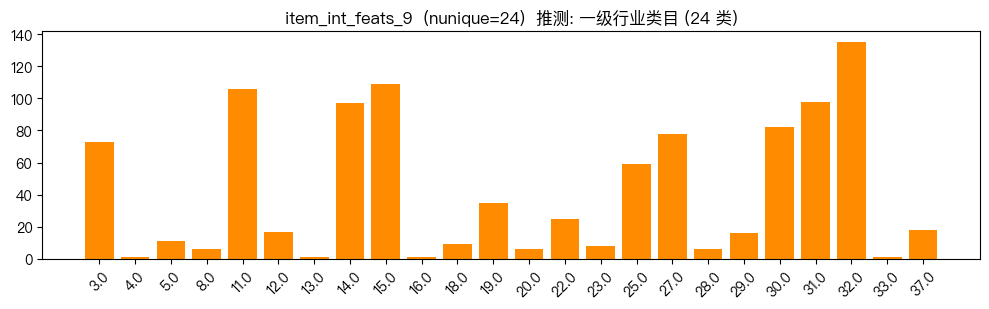

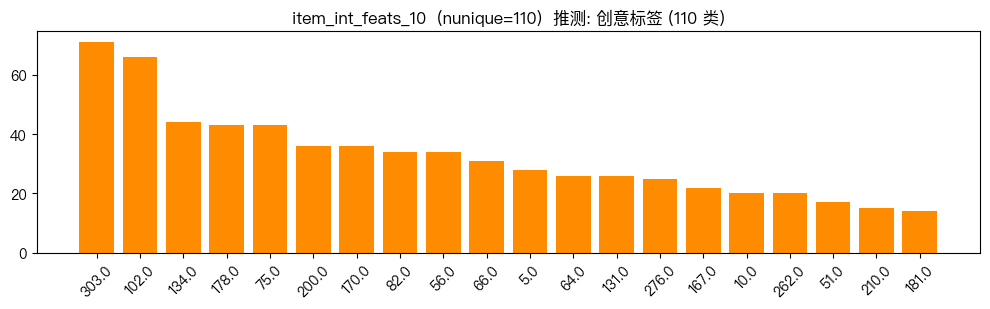

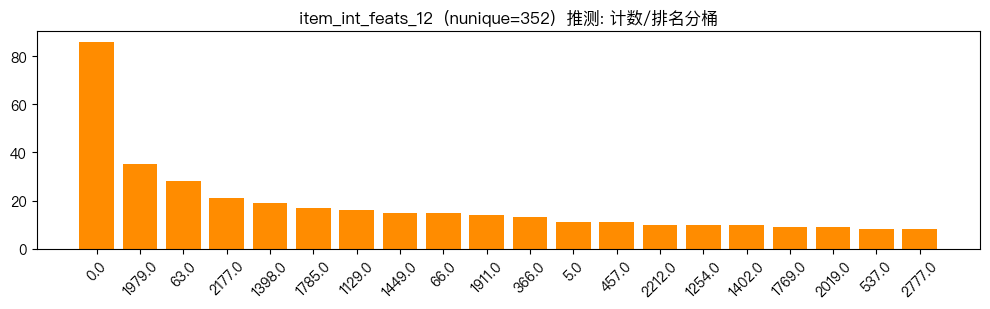

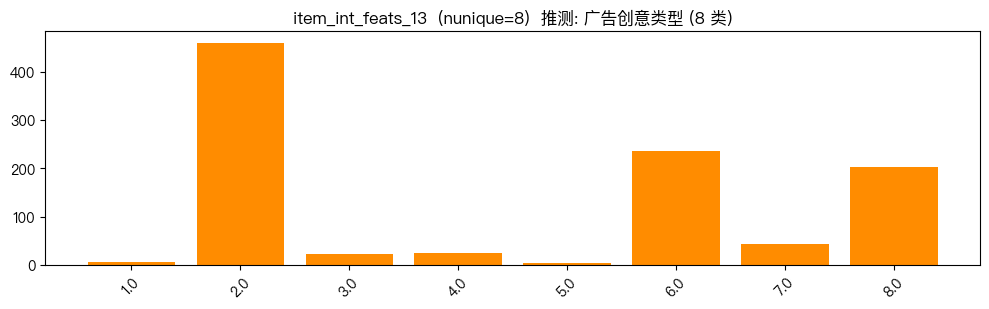

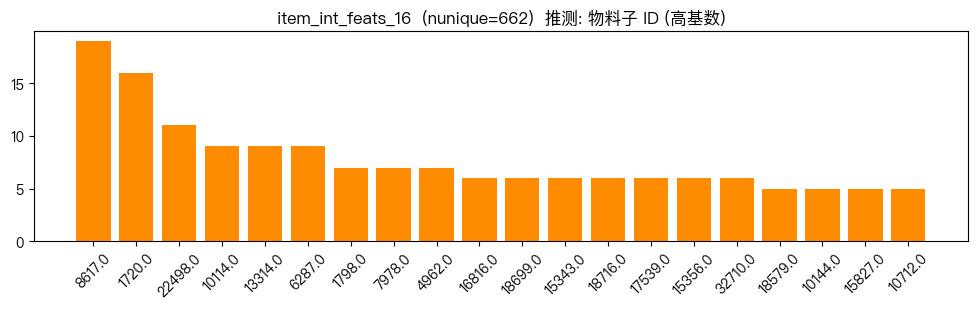

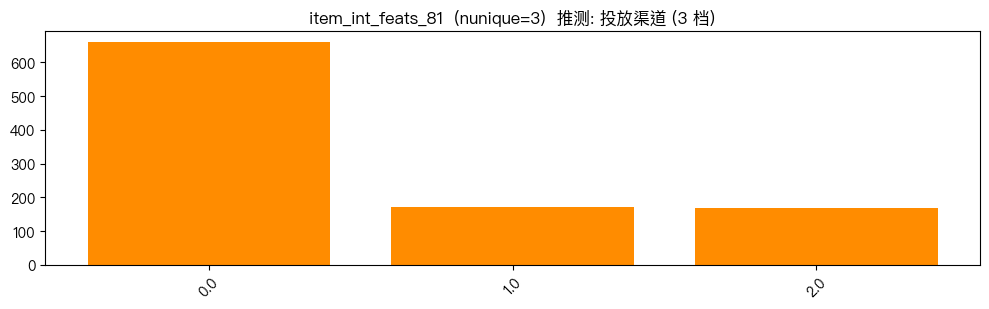

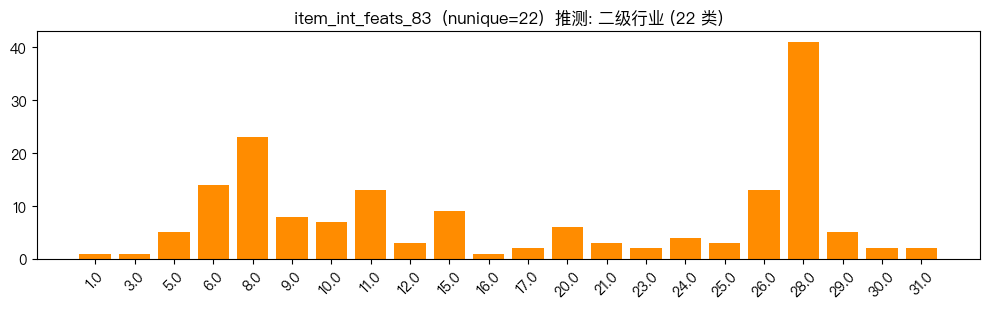

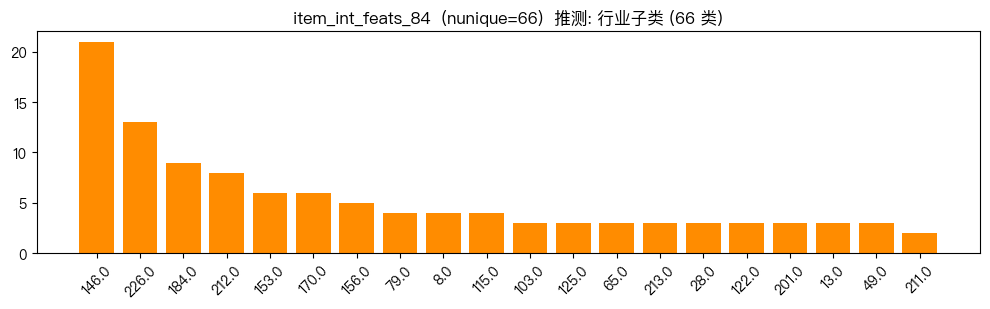

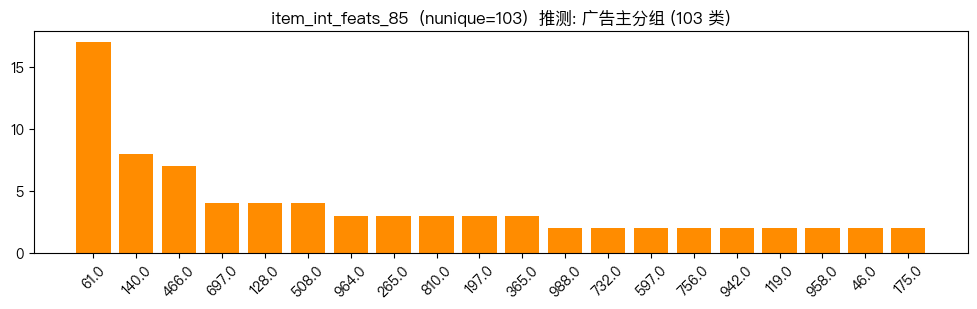

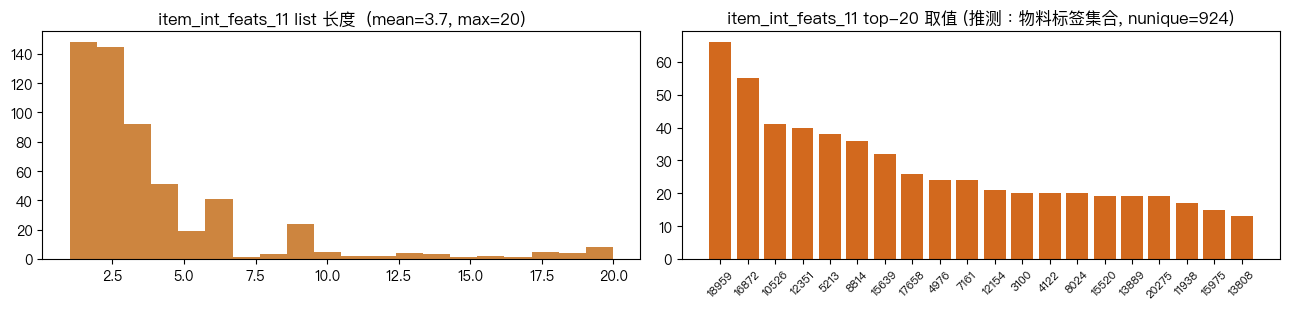

In [ ]:
item_int_cols = groups['item_int']
item_int_scalar = [c for c in item_int_cols if df[c].dtype != 'object']
item_int_list = [c for c in item_int_cols if df[c].dtype == 'object']

ITEM_GUESS = {
    'item_int_feats_13': '广告创意类型 (8 类)',
    'item_int_feats_81': '投放渠道 (3 档)',
    'item_int_feats_9': '一级行业类目 (24 类)',
    'item_int_feats_83': '二级行业 (22 类)',
    'item_int_feats_5': '三级品类 (82 类)',
    'item_int_feats_84': '行业子类 (66 类)',
    'item_int_feats_10': '创意标签 (110 类)',
    'item_int_feats_85': '广告主分组 (103 类)',
    'item_int_feats_6': '高基数行业细类',
    'item_int_feats_7': '计数/排名分桶',
    'item_int_feats_8': '计数/排名分桶 (含 -1)',
    'item_int_feats_12': '计数/排名分桶',
    'item_int_feats_16': '物料子 ID (高基数)',
}

# 标量列：低基数 -> 全量 bar；高基数 -> top-20
for c in item_int_scalar:
    s = df[c].dropna()
    if len(s) == 0:
        continue
    nu = s.nunique()
    fig, ax = plt.subplots(figsize=(10, 3.2))
    if nu <= 25:
        vc = s.value_counts().sort_index()
    else:
        vc = s.value_counts().head(20)
    ax.bar(vc.index.astype(str), vc.values, color='darkorange')
    title = f'{c}  (nunique={nu})'
    if c in ITEM_GUESS:
        title += f'  推测: {ITEM_GUESS[c]}'
    ax.set_title(title)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 多值列：list 长度 + top-20 取值
for c in item_int_list:
    s = df[c].dropna()
    if len(s) == 0:
        continue
    lens = s.apply(lambda x: len(x) if hasattr(x, '__len__') else 0)
    flat = explode_list_col(s)
    fig, axes = plt.subplots(1, 2, figsize=(13, 3.2))
    axes[0].hist(lens, bins=20, color='peru')
    axes[0].set_title(f'{c} list 长度  (mean={lens.mean():.1f}, max={lens.max()})')
    if len(flat) > 0:
        vc = pd.Series(flat).value_counts().head(20)
        axes[1].bar(vc.index.astype(str), vc.values, color='chocolate')
        axes[1].set_title(f'{c} top-20 取值 (推测：物料标签集合, nunique={pd.Series(flat).nunique()})')
        axes[1].tick_params(axis='x', rotation=45, labelsize=8)
    plt.tight_layout()
    plt.show()

## 7. 行为序列特征（domain_a/b/c/d）

四个 domain 各对应一类行为序列（参考 `dataset.py` / `ns_groups.json`）：

| Domain | 列数 | 推测语义 |
| --- | --- | --- |
| `domain_a` | 9 | 长行为序列（mean ≈ 700+，max=1888），最像 **跨场景/全站行为流**。包含 timestamp 字段（`*_seq_39`）|
| `domain_b` | 13 | 中长序列，包含一个 timestamp 字段 |
| `domain_c` | 12 | 中等序列 |
| `domain_d` | 10 | 较短序列，包含 timestamp 字段（`*_seq_26`）|

每个 domain 的多个 `seq_*` 列代表 **同一事件流的不同 side-info 字段**（一一对齐）：例如行为 ID、品类、子类、价格桶、时间戳等。

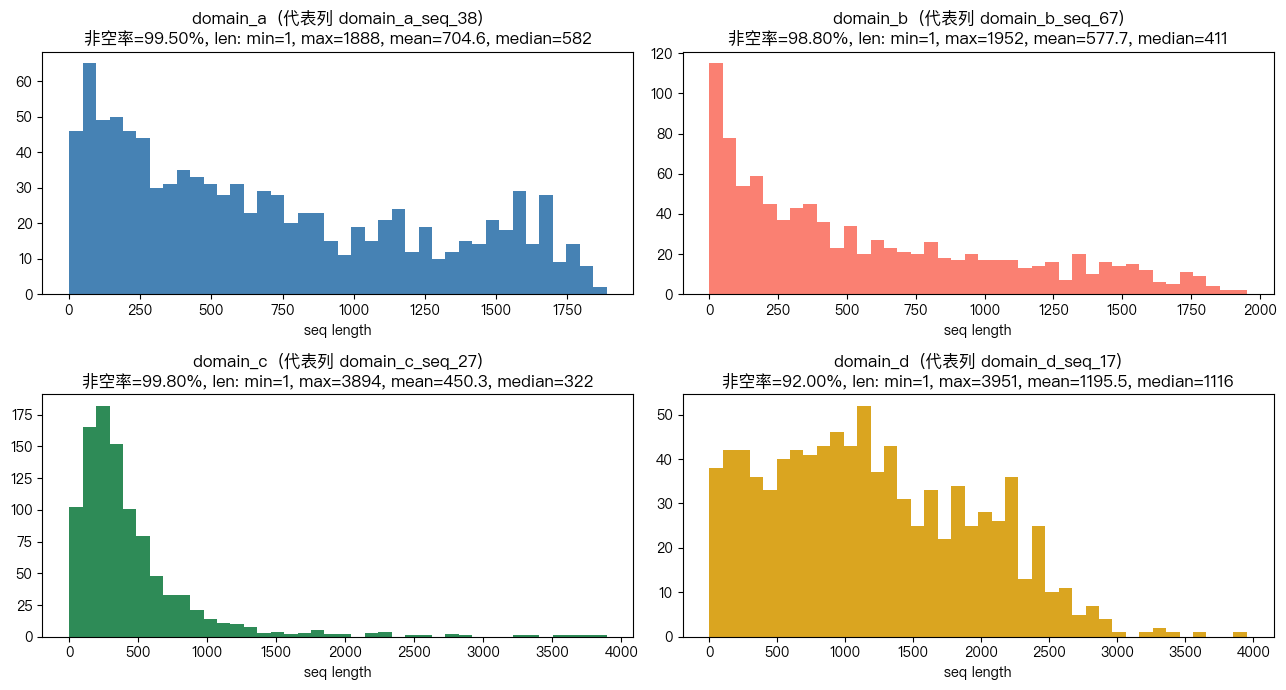

         mean    min    max
domain                     
a       0.005  0.005  0.005
b       0.012  0.012  0.012
c       0.002  0.002  0.002
d       0.080  0.080  0.080


In [ ]:
# 每个 domain 的整体长度分布（用每个 domain 的第一列代表）
domain_first = {
    'a': groups['seq_a'][0],
    'b': groups['seq_b'][0],
    'c': groups['seq_c'][0],
    'd': groups['seq_d'][0],
}

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
axes = axes.ravel()
for i, (k, c) in enumerate(domain_first.items()):
    s = df[c].dropna()
    lens = s.apply(lambda x: len(x) if hasattr(x, '__len__') else 0)
    null_rate = df[c].isnull().mean()
    axes[i].hist(lens, bins=40, color=['steelblue', 'salmon', 'seagreen', 'goldenrod'][i])
    axes[i].set_title(
        f'domain_{k}  (代表列 {c})\n'
        f'非空率={1-null_rate:.2%}, len: min={lens.min()}, max={lens.max()}, mean={lens.mean():.1f}, median={lens.median():.0f}'
    )
    axes[i].set_xlabel('seq length')
plt.tight_layout()
plt.show()

# 每个 domain 的 side-info 字段缺失率
rows = []
for k in 'abcd':
    for c in groups[f'seq_{k}']:
        rows.append({'domain': k, 'col': c, 'missing': df[c].isnull().mean()})
seq_missing = pd.DataFrame(rows)
print(seq_missing.groupby('domain')['missing'].agg(['mean', 'min', 'max']))

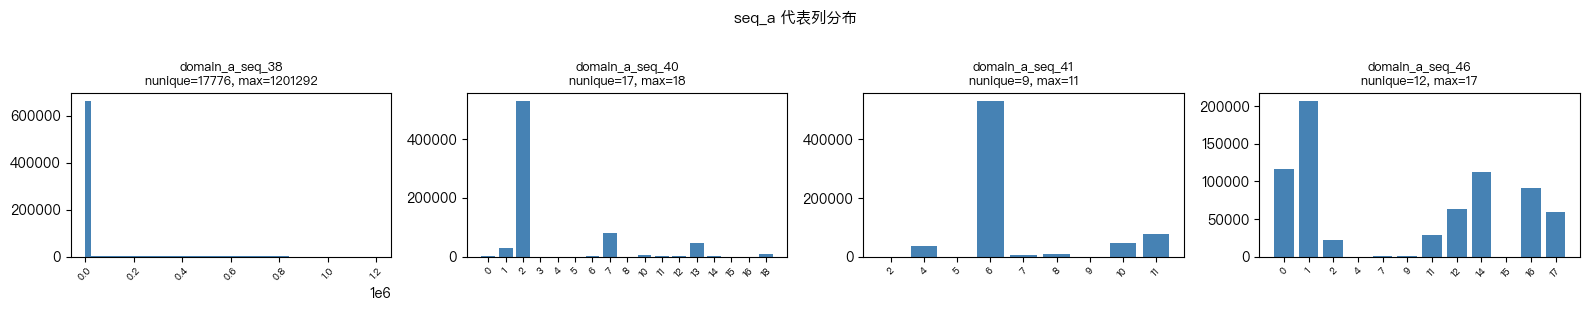

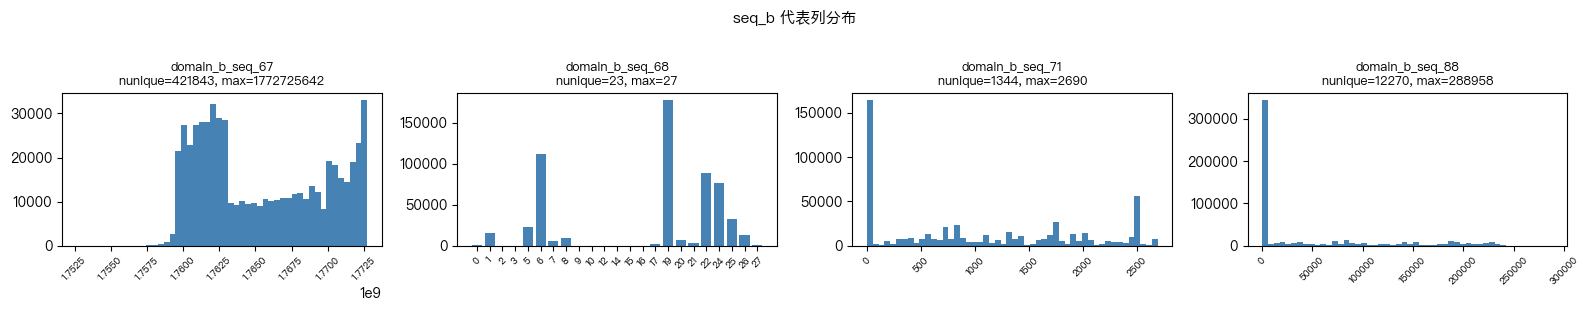

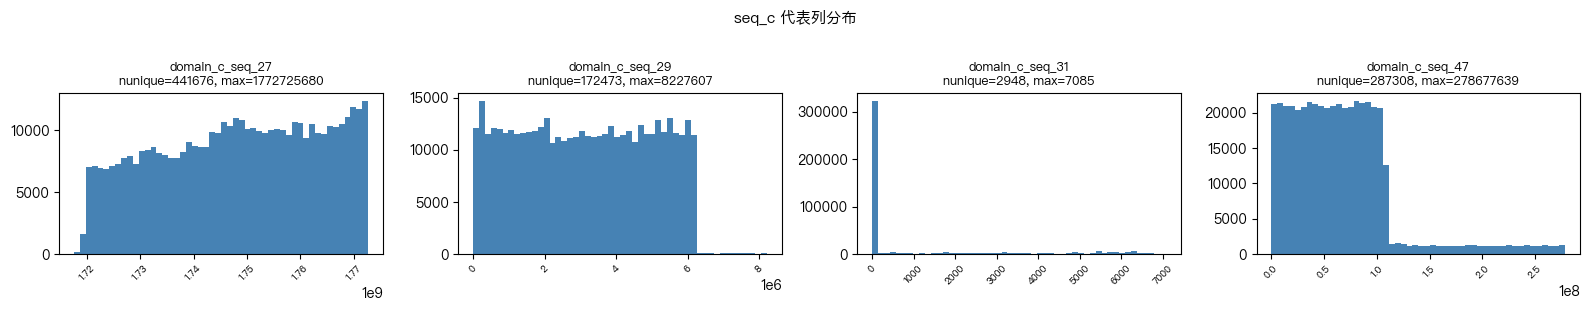

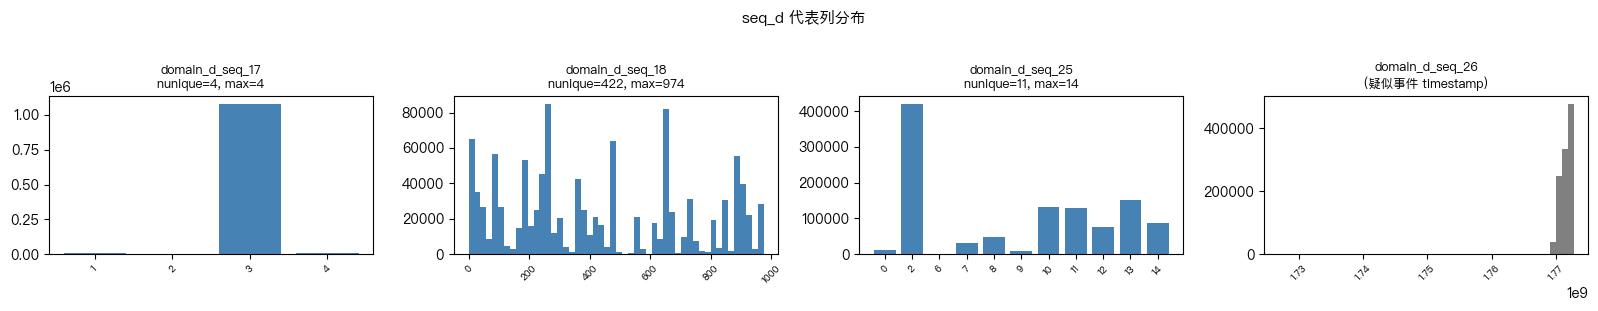

In [ ]:
# 每个 domain 取最多 4 列代表性 side-info 看取值分布
REPRESENT = {
    'seq_a': ['domain_a_seq_38', 'domain_a_seq_40', 'domain_a_seq_41', 'domain_a_seq_46'],
    'seq_b': ['domain_b_seq_67', 'domain_b_seq_68', 'domain_b_seq_71', 'domain_b_seq_88'],
    'seq_c': ['domain_c_seq_27', 'domain_c_seq_29', 'domain_c_seq_31', 'domain_c_seq_47'],
    'seq_d': ['domain_d_seq_17', 'domain_d_seq_18', 'domain_d_seq_25', 'domain_d_seq_26'],
}

for dom, cols in REPRESENT.items():
    cols = [c for c in cols if c in df.columns]
    fig, axes = plt.subplots(1, len(cols), figsize=(4 * len(cols), 3))
    if len(cols) == 1:
        axes = [axes]
    for ax, c in zip(axes, cols):
        flat = explode_list_col(df[c])
        if len(flat) == 0:
            ax.set_title(f'{c}\n(empty)')
            continue
        # 时间戳列特殊处理
        if c.endswith(('_39', '_88', '_26')) and flat.max() > 1e9:
            ax.hist(flat, bins=50, color='gray')
            ax.set_title(f'{c}\n(疑似事件 timestamp)', fontsize=9)
        else:
            nu = pd.Series(flat).nunique()
            if nu <= 30:
                vc = pd.Series(flat).value_counts().sort_index()
                ax.bar(vc.index.astype(str), vc.values, color='steelblue')
            else:
                ax.hist(flat, bins=50, color='steelblue')
            ax.set_title(f'{c}\nnunique={nu}, max={flat.max()}', fontsize=9)
        ax.tick_params(axis='x', rotation=45, labelsize=7)
    fig.suptitle(f'{dom} 代表列分布', y=1.02, fontsize=11)
    plt.tight_layout()
    plt.show()

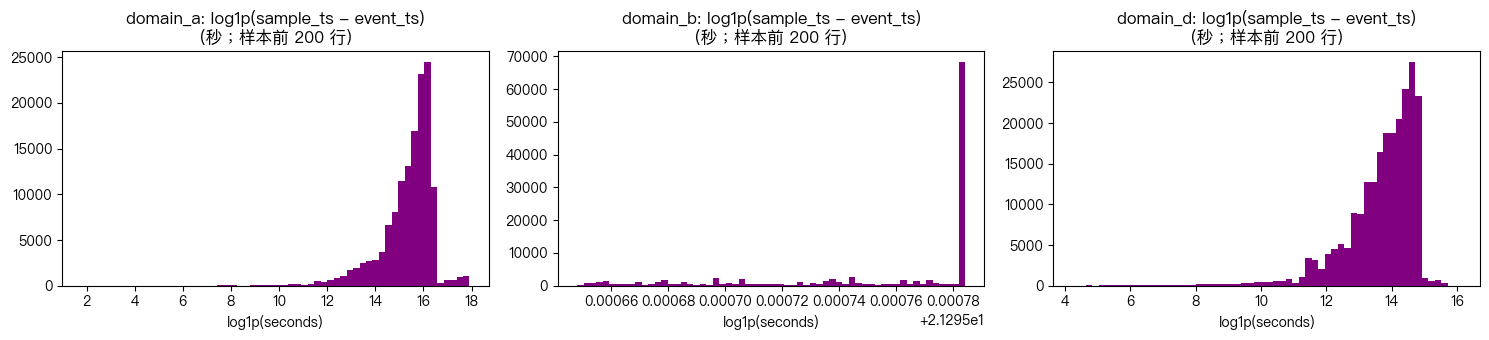

In [ ]:
# 时间桶：相对时间差（sample.timestamp - seq_event_timestamp）
ts_cols = {
    'a': 'domain_a_seq_39',
    'b': 'domain_b_seq_88',
    'd': 'domain_d_seq_26',
}

fig, axes = plt.subplots(1, len(ts_cols), figsize=(5 * len(ts_cols), 3.5))
for ax, (k, c) in zip(axes, ts_cols.items()):
    deltas = []
    sub = df[df[c].notna()][[c, 'timestamp']].head(200)
    for _, row in sub.iterrows():
        seq_ts = np.array(row[c])
        d = row['timestamp'] - seq_ts
        deltas.extend(d.tolist())
    deltas = np.array(deltas)
    deltas = deltas[deltas >= 0]
    # log 时间差更清晰
    log_d = np.log1p(deltas)
    ax.hist(log_d, bins=60, color='purple')
    ax.set_title(f'domain_{k}: log1p(sample_ts - event_ts)\n(秒；样本前 200 行)')
    ax.set_xlabel('log1p(seconds)')
plt.tight_layout()
plt.show()

## 8. 标签 × 关键特征 交叉分析

用 `label_type` 当作目标，看几个低基数标量特征的条件分布。这能初步看出哪些字段对 `label_type` 有判别力。

/var/folders/k2/44nzlkx90_j4c413x3bdhd680000gn/T/ipykernel_96393/1922579106.py:35: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) PingFang HK.
  plt.tight_layout()


/Users/gaogang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) PingFang HK.
  fig.canvas.print_figure(bytes_io, **kw)


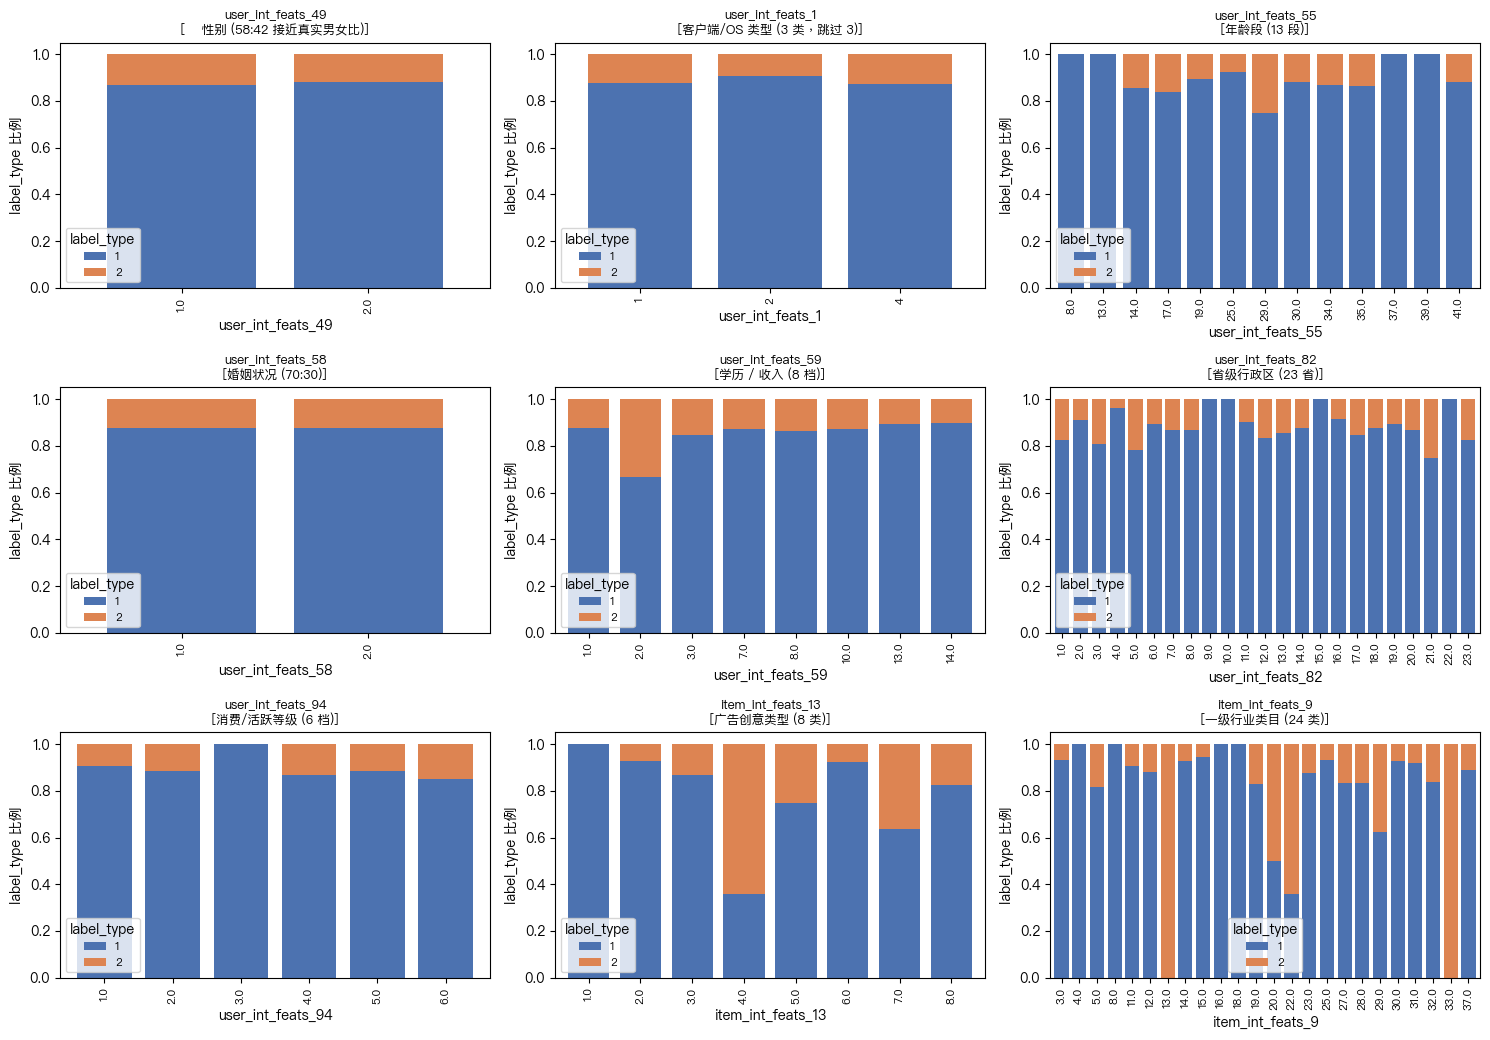

In [ ]:
# 修订：把真正怀疑是性别的 user_int_feats_49 和 OS/平台 user_int_feats_1 都纳入对比
key_cols = [
    'user_int_feats_49',  # ⭐ 性别（修订）
    'user_int_feats_1',   # 客户端/OS（原误判为性别）
    'user_int_feats_55',  # 年龄段
    'user_int_feats_58',  # 婚姻
    'user_int_feats_59',  # 学历
    'user_int_feats_82',  # 省份
    'user_int_feats_94',  # 消费等级
    'item_int_feats_13',  # 创意类型
    'item_int_feats_9',   # 一级行业
]

ncols = 3
nrows = (len(key_cols) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.5 * nrows))
axes = np.atleast_2d(axes).reshape(nrows, ncols)

for i, c in enumerate(key_cols):
    ax = axes[i // ncols][i % ncols]
    ct = pd.crosstab(df[c], df['label_type'])
    ct_norm = ct.div(ct.sum(axis=1), axis=0)
    ct_norm.plot(kind='bar', stacked=True, ax=ax, color=['#4c72b0', '#dd8452'], width=0.8)
    title = c
    if c in {**GUESS, **ITEM_GUESS}:
        g = GUESS.get(c) or ITEM_GUESS.get(c)
        title += f'\n[{g}]'
    ax.set_title(title, fontsize=9)
    ax.set_ylabel('label_type 比例')
    ax.legend(title='label_type', fontsize=8)
    ax.tick_params(axis='x', labelsize=8)

for i in range(len(key_cols), nrows * ncols):
    axes[i // ncols][i % ncols].axis('off')
plt.tight_layout()
plt.show()

## 9. 特征语义猜测汇总（修订版）

下表是基于 1000 行 sample data 的**修订版**推测，重点订正：
- `user_int_feats_49` 才是真实**性别**（二值、58:42、缺失率仅 0.7%）；
- `user_int_feats_1` 不是性别，是 **客户端/OS 类型**（编码 1/2/4 跳过 3，4 占 77.6% 符合 Android 主导）；
- `user_int_feats_92` 不是人口字段，是 **实验组/流量分桶**（完美 50:50 + 缺失率 49.4%）；
- `user_int_feats_82` 23 档对应**中国 23 省**（不含直辖市、自治区、港澳台），是省份的最强候选；
- `user_int_feats_55` 13 段、`user_int_feats_59` 8 档、`user_int_feats_94` 6 档分别对应**年龄段 / 学历 / 消费等级**。

> 真值仍以官方 schema 为准。

### 9.1 用户字段（修订）

| 字段 | 类型 | 修订推测 | 主要依据 |
| --- | --- | --- | --- |
| **`user_int_feats_49`** ⭐ | scalar (2) | **性别** | 58:42 比例 + 缺失 0.7%（强制采集字段）|
| `user_int_feats_1` | scalar (3) | 客户端 / OS 类型 | 编码 {1,2,4} 跳过 3；4 占 77.6%（Android）|
| `user_int_feats_50` | scalar (2) | 是否实名 / 是否已激活 | 994:2 极度倾斜 |
| `user_int_feats_51` | scalar (5) | 用户类型 (默认值) | 56 占 99.5% |
| `user_int_feats_55` | scalar (13) | **年龄段** (13 段) | 离散等级 |
| `user_int_feats_58` | scalar (2) | 婚姻状况 / 是否已婚 | 70:30 |
| `user_int_feats_59` | scalar (8) | **学历** / 收入档 (8 档) | 8 档常见于学历分层 |
| `user_int_feats_82` | scalar (23) | **省份**（中国 23 省）| 23 = 中国大陆 23 省（不含直辖市/自治区/港澳台）|
| `user_int_feats_48` | scalar (52) | 城市等级 / 城市分档 | 中等基数，可能是地级市或一二三四五线分档 |
| `user_int_feats_52` | scalar (36) | 一级行业兴趣 (36 档) | 36 接近行业一级分类常用数 |
| `user_int_feats_92` | scalar (2) | **实验组 / 流量分桶** | 完美 50:50 + 缺失率 49.4% |
| `user_int_feats_93` | scalar (36) | 兴趣大类 / 二级地域 | 与 52 同构 |
| `user_int_feats_94` | scalar (6) | **消费 / 活跃等级** (6 档) | RFM 常用 6 档 |
| `user_int_feats_95-109` | scalar (2/3) | **兴趣偏好等级组**（多品类兴趣强度 1=低 / 2=中 / 3=高，未触达=NaN）| 取值同构 + 缺失率递增 |
| `user_int_feats_3` | scalar (341) | 城市/POI ID | 接近中国 333 地级市 |
| `user_int_feats_4` | scalar (268) | 区县 ID | 高基数 |
| `user_int_feats_53/54/56/57/86` | scalar (中-高基数) | 兴趣类目 / 二三级类目 | 中-高基数离散 |
| `user_int_feats_15/60/63-66/80` | list (变长) | 兴趣标签 / 关注品类 集合 | 多值 ID 列 |
| `user_int_feats_62/63/64/65/66` | list ↔ dense 对齐 | **兴趣 ID + 权重对**（每个 ID 对应 dense 中一个统计值）| `ns_groups.json` 注明二者 element-wise 对齐 |
| `user_int_feats_89/90/91` | list (定长 10) | Top-10 兴趣 ID 序列 | 定长 + 配套 dense 评分 |
| `user_dense_feats_61` | dense (256 维) | 用户预训练向量 | 标准 embedding 形态 |
| `user_dense_feats_87` | dense (320 维) | 用户跨场景表征 | 标准 embedding 形态 |
| `user_dense_feats_89/90/91` | dense (10 维) | 与兴趣 ID 对齐的偏好分数 | 与对应 int list 一一对齐 |
| `user_dense_feats_62-66` | dense (变长) | 计数/求和聚合统计 | 量级 1e2 ~ 1e7，对齐 user_int_feats_62-66 |

### 9.2 物料字段（小幅修订）

| 字段 | 类型 | 修订推测 | 主要依据 |
| --- | --- | --- | --- |
| `item_int_feats_5` | scalar (82) | 三级品类 / 创意子类 | 中基数 |
| `item_int_feats_6` | scalar (216) | 广告主行业 / 高基数行业细类 | 高基数 |
| `item_int_feats_7` | scalar (349) | 计数 / 排名分桶 | 高基数 + 取值从 0 开始 |
| `item_int_feats_8` | scalar (226, 含 -1) | 计数 / 排名分桶（-1 = 缺失码）| -1 是常见的"未知"哨兵 |
| **`item_int_feats_9`** | scalar (24) | **一级行业类目** (24 类) | 24 接近常见广告行业一级分类 |
| `item_int_feats_10` | scalar (110) | 创意标签 | 中基数 |
| `item_int_feats_11` | list | 物料标签集合 | 多值 ID 列 |
| `item_int_feats_12` | scalar (352) | 计数 / 排名分桶 | 高基数 |
| **`item_int_feats_13`** | scalar (8) | **广告创意类型** (图文/视频/横幅/...) | 8 类典型创意分类 |
| `item_int_feats_16` | scalar (662) | 物料子 ID（高基数）| 高基数 |
| **`item_int_feats_81`** | scalar (3) | **投放渠道** (3 档) | 3 档典型流量来源 |
| `item_int_feats_83/84/85` | scalar | 二级行业 / 子类 / 广告主分组 | 中基数 |

### 9.3 序列字段

| Domain | 列数 | 长度 | 缺失率 | 推测含义 |
| --- | --- | --- | --- | --- |
| `domain_a` | 9 | mean ≈ 700, max=1888 | ~0.5% | **跨场景全站行为流**，含事件 timestamp `*_seq_39` |
| `domain_b` | 13 | 中长 | 较高 | **特定场景行为**（如 App 内信息流），含 timestamp `*_seq_88` |
| `domain_c` | 12 | 中等 | 较高 | 另一种行为（如搜索 / 收藏）|
| `domain_d` | 10 | 较短 | ~30% | **广告侧行为流**（曝光 / 点击 / 下单），含 timestamp `*_seq_26` |

每个 domain 内的多列对应同一事件流的不同 side-info：行为 ID / 品类 / 子类 / 价格桶 / 时间戳……一行内列与列等长一一对齐。

### 9.4 标签

- `label_type=1` (876)：浅层转化 / 主流行为；
- `label_type=2` (124)：深层 / 稀有转化。
  PCVR 任务下可考虑：(a) 仅预测某一类，(b) 多任务联合建模，(c) `label_type=2` 作为辅助监督信号。

In [ ]:
# 把推测表导出为 DataFrame，方便后续与 schema.json 对照
all_guess = {**GUESS, **ITEM_GUESS}
rows = []
for c in df.columns:
    s = df[c].dropna()
    if df[c].dtype == 'object':
        ftype = 'list'
        nu = ''
    else:
        ftype = str(df[c].dtype)
        nu = s.nunique() if len(s) else 0
    rows.append({
        'col': c,
        'family': classify(c),
        'dtype': ftype,
        'nunique': nu,
        'missing': round(df[c].isnull().mean(), 4),
        'guess': all_guess.get(c, ''),
    })
summary_df = pd.DataFrame(rows)
summary_df.head(30)

,col,family,dtype,nunique,missing,guess
0,user_id,meta,int64,1000,0.000,
1,item_id,meta,int64,837,0.000,
2,label_type,meta,int32,2,0.000,
3,label_time,meta,int64,553,0.000,
4,timestamp,meta,int64,501,0.000,
5,user_int_feats_1,user_int,int64,3,0.000,客户端/OS 类型 (3 类，跳过 3)
6,user_int_feats_3,user_int,float64,341,0.030,
7,user_int_feats_4,user_int,float64,268,0.030,
8,user_int_feats_15,user_int,list,,0.139,
9,user_int_feats_48,user_int,float64,52,0.002,城市等级 / 城市分档 (52)


In [ ]:
summary_df.to_csv('sample_data_feature_summary.csv', index=False)
print('已保存到 sample_data_feature_summary.csv')
print('共', len(summary_df), '列')

已保存到 sample_data_feature_summary.csv
共 120 列
